In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap
from module import FlowMatchingModel

In [2]:
class BottleneckExtractor:
    def __init__(self, checkpoint_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = FlowMatchingModel.load_from_checkpoint(checkpoint_path)
        self.model.to(self.device)
        self.model.eval()
        
        self.bottleneck_features = []
        self.model.scalar_field.bottleneck.register_forward_hook(self._hook_fn)
        
    def _hook_fn(self, module, input, output):
        pooled = torch.mean(output, dim=[2, 3])  # Global average pooling
        self.bottleneck_features.append(pooled.detach().cpu())
    
    def extract_features(self, total_mass_maps, star_maps, gas_maps, astro_params, batch_size=25):
        """Extract features in small batches to avoid memory issues"""
        all_batch_features = []
        n_samples = len(total_mass_maps)
        
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            
            # Clear previous features
            self.bottleneck_features = []
            
            # Get batch slices
            batch_total = total_mass_maps[i:end_idx]
            batch_star = star_maps[i:end_idx] 
            batch_gas = gas_maps[i:end_idx]
            
            # Handle astro_params indexing
            astro_start = i // 15
            astro_end = min((end_idx + 14) // 15, len(astro_params))
            batch_astro = astro_params[astro_start:astro_end]
            
            # Convert to tensors
            total_mass = torch.FloatTensor(batch_total).unsqueeze(1).to(self.device)
            target_maps = torch.stack([
                torch.FloatTensor(batch_star),
                torch.FloatTensor(batch_gas)
            ], dim=1).to(self.device)
            astro_params_tensor = torch.FloatTensor(batch_astro).to(self.device)
            
            # Create forward pass
            current_batch_size = total_mass.size(0)
            t = torch.rand(current_batch_size, device=self.device)
            
            x0 = total_mass.expand(-1, 2, -1, -1)
            x1 = target_maps
            t_expanded = t.view(-1, 1, 1, 1)
            x_t = (1 - t_expanded) * x0 + t_expanded * x1
            
            # Handle astro_params batch size matching
            if astro_params_tensor.size(0) != current_batch_size:
                repeat_factor = (current_batch_size + astro_params_tensor.size(0) - 1) // astro_params_tensor.size(0)
                astro_params_tensor = astro_params_tensor.repeat(repeat_factor, 1)[:current_batch_size]
            
            condition_param = torch.cat([t.unsqueeze(1), astro_params_tensor], dim=1)
            
            with torch.no_grad():
                _ = self.model.scalar_field(x_t, condition_param, total_mass, target_maps)
            
            # Collect batch features
            if self.bottleneck_features:
                batch_features = torch.cat(self.bottleneck_features, dim=0).cpu().numpy()
                all_batch_features.append(batch_features)
            
            # Clear GPU memory immediately
            del total_mass, target_maps, astro_params_tensor, x_t, condition_param
            torch.cuda.empty_cache()
        
        # Combine all batches
        if all_batch_features:
            return np.vstack(all_batch_features)
        return np.array([])

def load_model_data(model_name, n_samples=500, data_dir="/n/netscratch/iaifi_lab/Lab/msliu/CMD/data"):
    """Load and normalize data following training pattern exactly"""
    
    # Load full datasets
    # total_mass = np.load(f'{data_dir}/{model_name}/Maps_Mtot_{model_name}_LH_z=0.00.npy')
    total_mass = np.load(f'{data_dir}/{model_name}/Maps_Mcdm_{model_name}_LH_z=0.00.npy')
    star_maps = np.load(f'{data_dir}/{model_name}/Maps_Mstar_{model_name}_LH_z=0.00.npy')
    gas_maps = np.load(f'{data_dir}/{model_name}/Maps_Mgas_{model_name}_LH_z=0.00.npy')
    params = np.loadtxt(f'{data_dir}/{model_name}/params_LH_{model_name}.txt')
    
    # Apply log1p transformation (training pattern)
    total_mass_log = np.log1p(total_mass)
    star_maps_log = np.log1p(star_maps)
    gas_maps_log = np.log1p(gas_maps)
    
    # Compute normalization from full dataset
    tot_mean, tot_std = total_mass_log.mean(), total_mass_log.std()
    star_mean, star_std = star_maps_log.mean(), star_maps_log.std()
    gas_mean, gas_std = gas_maps_log.mean(), gas_maps_log.std()
    
    # Sample and normalize
    if len(total_mass_log) > n_samples:
        indices = np.random.choice(len(total_mass_log), n_samples, replace=False)
        total_mass = (total_mass_log[indices] - tot_mean) / tot_std
        star_maps = (star_maps_log[indices] - star_mean) / star_std
        gas_maps = (gas_maps_log[indices] - gas_mean) / gas_std
        cosmo_params = params[indices//15, :2]  
        astro_params = params[indices//15, 2:]  
    else:
        total_mass = (total_mass_log - tot_mean) / tot_std
        star_maps = (star_maps_log - star_mean) / star_std
        gas_maps = (gas_maps_log - gas_mean) / gas_std
        cosmo_params = np.repeat(params[:,:2],15,axis=0)
        astro_params = np.repeat(params[:,2:],15,axis=0)
    
    return total_mass, star_maps, gas_maps, cosmo_params, astro_params

In [3]:
def features_extraction(checkpoint_path='lightning_logs/FM_dm_all/checkpoints/best-model-epoch=94-val_loss=0.026710.ckpt', 
                        simulation_models=['IllustrisTNG', 'EAGLE', 'SIMBA', 'Astrid','Magneticum'], 
                        n_samples_per_model=5000):
    
    print("Extracting bottleneck features...")
    
    # Load model once
    extractor = BottleneckExtractor(checkpoint_path)
    
    # Collect features from all models
    all_features = []
    all_labels = []
    all_astro_params = []
    all_cosmo_params = []
    
    for model_name in simulation_models:
        print(f"Processing {model_name}...")
        
        # Load data
        total_mass, star_maps, gas_maps, cosmo_params, astro_params = load_model_data(
            model_name, n_samples_per_model
        )
        
        # Extract features in small batches
        features = extractor.extract_features(
            total_mass, star_maps, gas_maps, cosmo_params, batch_size=25
        )
        
        if len(features) > 0:
            all_features.append(features)
            all_labels.extend([model_name] * len(features))
            print(f"  Extracted {len(features)} features")
    
        all_astro_params.append(astro_params)
        all_cosmo_params.append(cosmo_params)
        
        # Clear memory between models
        torch.cuda.empty_cache()
        print(f"  Memory cleared after {model_name}")
    
    # Combine and reduce dimensions
    print(f"Total features: {np.vstack(all_features).shape}")

    return all_features, all_labels, all_astro_params, all_cosmo_params

In [4]:
all_features, all_labels, all_astro_params, all_cosmo_params = features_extraction()

Extracting bottleneck features...
Processing IllustrisTNG...
  Extracted 5000 features
  Memory cleared after IllustrisTNG
Processing EAGLE...
  Extracted 5000 features
  Memory cleared after EAGLE
Processing SIMBA...
  Extracted 5000 features
  Memory cleared after SIMBA
Processing Astrid...
  Extracted 5000 features
  Memory cleared after Astrid
Processing Magneticum...
  Extracted 720 features
  Memory cleared after Magneticum
Total features: (20720, 512)


In [4]:
print("Running UMAP...")
# reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
stacked_features = np.vstack(all_features)
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_umap = reducer.fit_transform(stacked_features)

Running UMAP...


/n/home02/msliu/.conda/envs/env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


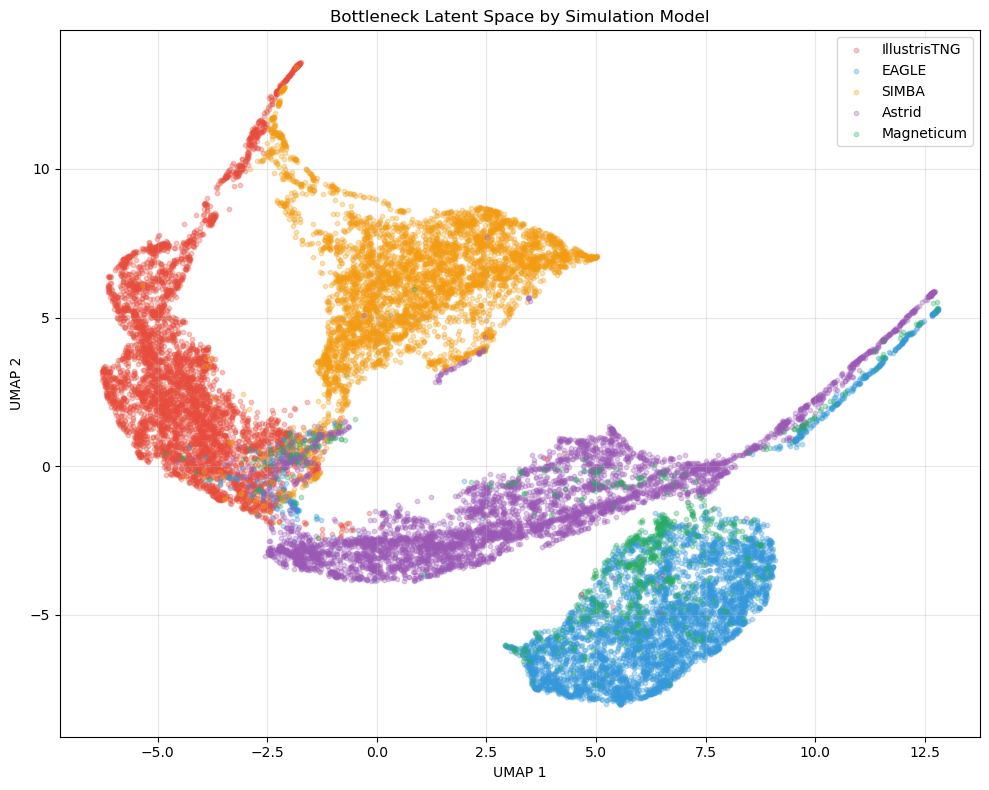

Visualization saved. Total samples: 20720


In [5]:
# Visualize
plt.figure(figsize=(10, 8))
colors = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6', '#27AE60']

for i, model_name in enumerate(simulation_models):
    mask = [label == model_name for label in all_labels]
    plt.scatter(embedding_umap[mask, 0], embedding_umap[mask, 1], 
               c=colors[i], label=model_name, alpha=0.3, s=10)

plt.title('Bottleneck Latent Space by Simulation Model')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("umap_visualisation_dm.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Visualization saved. Total samples: {len(embedding_umap)}")


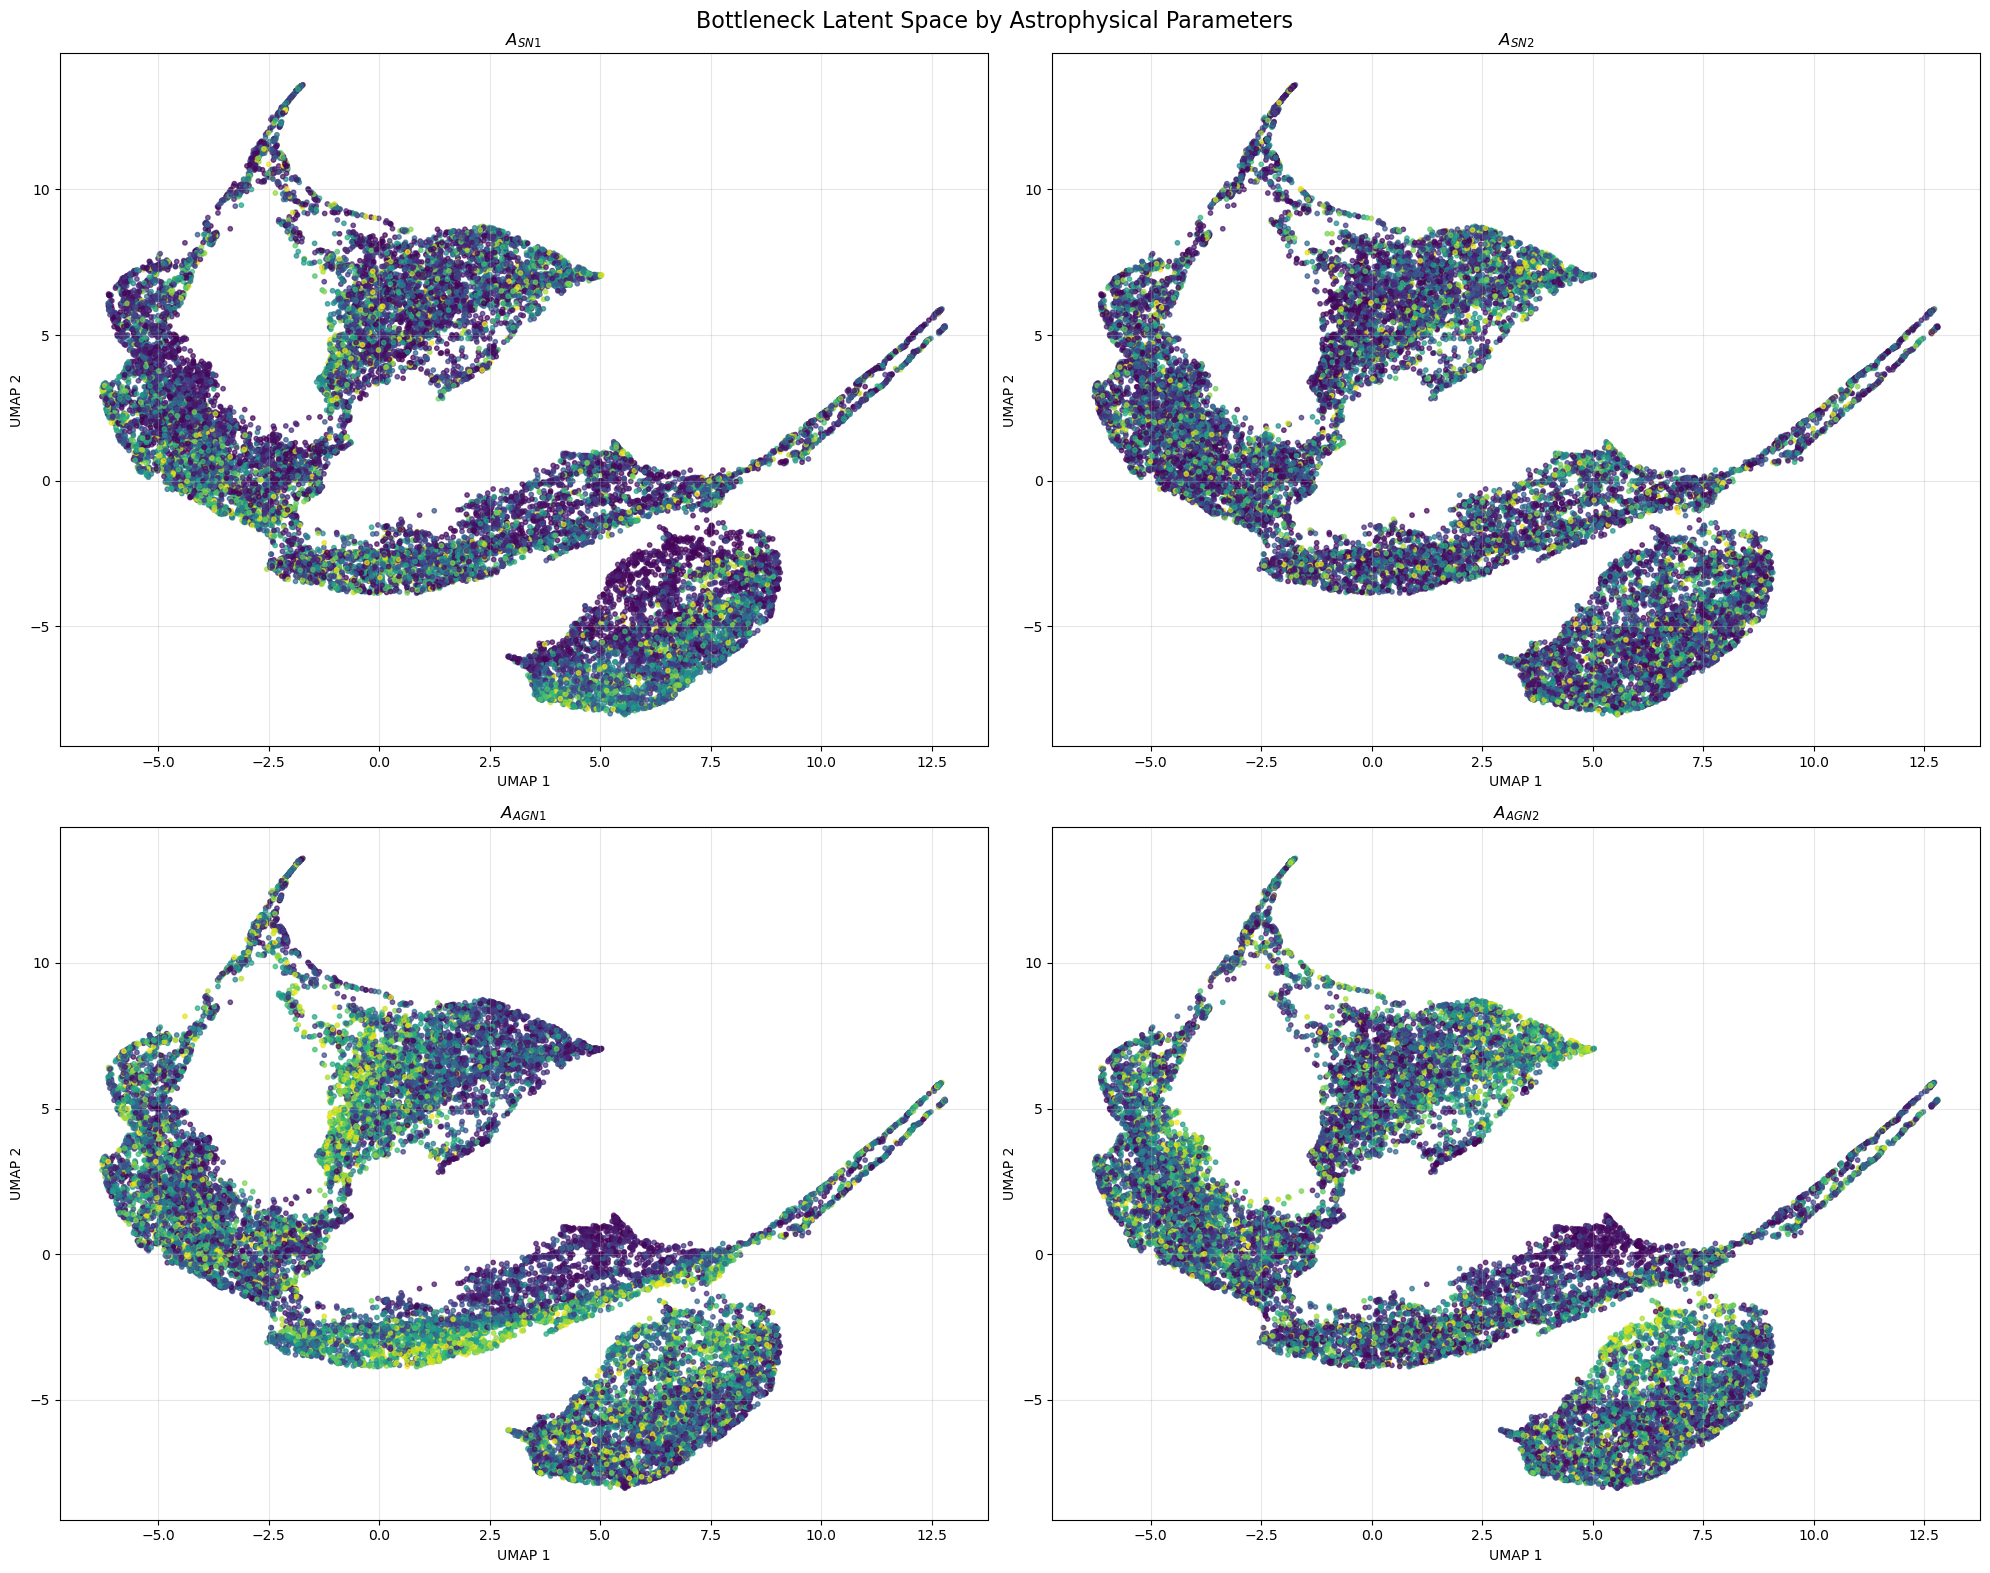

In [10]:
# Visualize Astrophysical Parameters
plt.figure(figsize=(20, 16))
colors = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6']
titles = ['$A_{SN1}$','$A_{SN2}$','$A_{AGN1}$','$A_{AGN2}$']
all_astro_params = np.asarray(all_astro_params[:4])

for i, title in enumerate(titles):
    plt.subplot(2,2,i+1)

    for j, model_name in enumerate(simulation_models[:4]):
        mask = [label == model_name for label in all_labels]
        plt.scatter(embedding_umap[mask, 0], embedding_umap[mask, 1], 
                   c=all_astro_params[j,:,i], alpha=0.7, s=10)
        
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.grid(True, alpha=0.3)
    plt.title(title)

plt.suptitle('Bottleneck Latent Space by Astrophysical Parameters', fontsize=16)
plt.tight_layout()
plt.savefig("umap_visualization_astro.png", dpi=300, bbox_inches='tight')
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\O'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\O'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4133610/3614126333.py:4: SyntaxWarning: invalid escape sequence '\O'
  titles = ['$\Omega_m$','$\sigma_8$']
/tmp/ipykernel_4133610/3614126333.py:4: SyntaxWarning: invalid escape sequence '\s'
  titles = ['$\Omega_m$','$\sigma_8$']


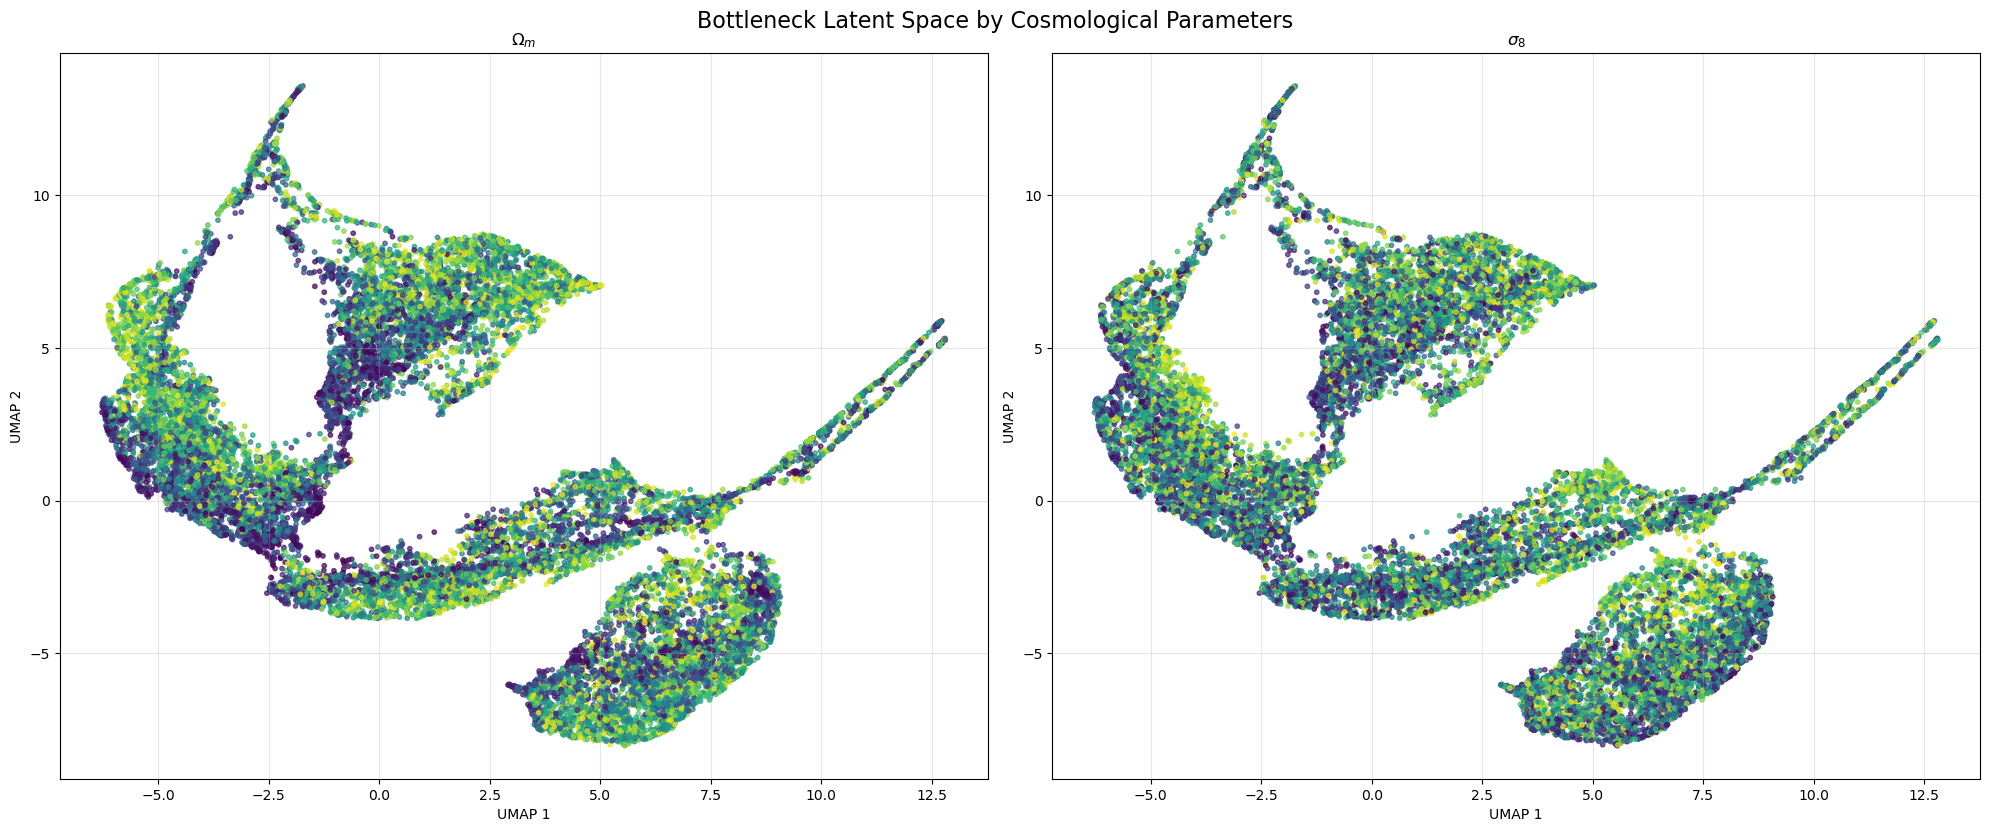

In [12]:
# Visualize Cosmological Parameters
plt.figure(figsize=(20, 16))
colors = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6']
titles = ['$\Omega_m$','$\sigma_8$']
all_cosmo_params = np.asarray(all_cosmo_params[:4])
all_cosmo_params_models = all_cosmo_params.reshape(4,5000,2)

for i, title in enumerate(titles):
    plt.subplot(2,2,i+1)

    for j, model_name in enumerate(simulation_models[:4]):
        mask = [label == model_name for label in all_labels]
        plt.scatter(embedding_umap[mask, 0], embedding_umap[mask, 1], 
                   c=all_cosmo_params_models[j,:,i], alpha=0.7, s=10)
        
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.grid(True, alpha=0.3)
    plt.title(title)

plt.suptitle('Bottleneck Latent Space by Cosmological Parameters', fontsize=16)
plt.tight_layout()
plt.savefig("umap_visualization_cosmo.png", dpi=300, bbox_inches='tight')
plt.show()

Running t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 20720 samples in 0.004s...
[t-SNE] Computed neighbors for 20720 samples in 9.875s...
[t-SNE] Computed conditional probabilities for sample 1000 / 20720
[t-SNE] Computed conditional probabilities for sample 2000 / 20720
[t-SNE] Computed conditional probabilities for sample 3000 / 20720
[t-SNE] Computed conditional probabilities for sample 4000 / 20720
[t-SNE] Computed conditional probabilities for sample 5000 / 20720
[t-SNE] Computed conditional probabilities for sample 6000 / 20720
[t-SNE] Computed conditional probabilities for sample 7000 / 20720
[t-SNE] Computed conditional probabilities for sample 8000 / 20720
[t-SNE] Computed conditional probabilities for sample 9000 / 20720
[t-SNE] Computed conditional probabilities for sample 10000 / 20720
[t-SNE] Computed conditional probabilities for sample 11000 / 20720
[t-SNE] Computed conditional probabilities for sample 12000 / 20720
[t-SNE] Computed conditional prob

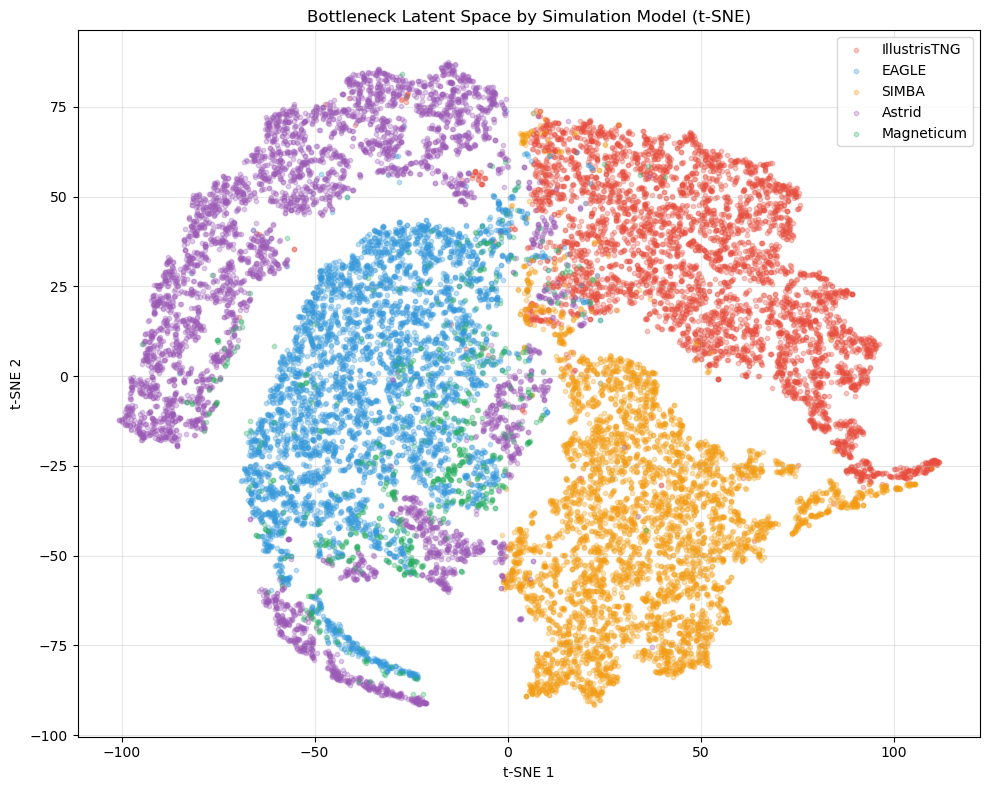

Visualization saved. Total samples: 20720


In [13]:
print("Running t-SNE...")
# Import t-SNE if not already imported
from sklearn.manifold import TSNE

stacked_features = np.vstack(all_features)
# reducer = TSNE(perplexity=30, max_iter=1000, random_state=42)
reducer = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, verbose=1)
embedding_tsne = reducer.fit_transform(stacked_features)

# Visualize
plt.figure(figsize=(10, 8))
colors = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6', '#27AE60']
for i, model_name in enumerate(simulation_models):
    mask = [label == model_name for label in all_labels]
    plt.scatter(embedding_tsne[mask, 0], embedding_tsne[mask, 1], 
               c=colors[i], label=model_name, alpha=0.3, s=10)
plt.title('Bottleneck Latent Space by Simulation Model (t-SNE)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tsne_visualisation_dm_wMag.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Visualization saved. Total samples: {len(embedding_tsne)}")

In [14]:
#### ResNet Features ####
class ResNetBottleneckExtractor:
    def __init__(self, checkpoint_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = FlowMatchingModel.load_from_checkpoint(checkpoint_path)
        self.model.to(self.device)
        self.model.eval()
        
        self.features = []
        self.model.scalar_field.resnet_branch.avgpool.register_forward_hook(self._hook_fn)
        
    def _hook_fn(self, module, input, output):
        self.features.append(output.view(output.size(0), -1).detach().cpu())
    
    def extract_features(self, total_mass, star_maps, gas_maps, astro_params, batch_size=25):
        all_features = []
        n_samples = len(total_mass)
        
        for i in range(0, n_samples, batch_size):
            self.features = []
            end_idx = min(i + batch_size, n_samples)
            
            # Prepare batch tensors
            total_mass_batch = torch.FloatTensor(total_mass[i:end_idx]).unsqueeze(1).to(self.device)
            target_maps = torch.stack([
                torch.FloatTensor(star_maps[i:end_idx]),
                torch.FloatTensor(gas_maps[i:end_idx])
            ], dim=1).to(self.device)
            
            # Handle astro params
            astro_start = i // 15
            astro_end = min((end_idx + 14) // 15, len(astro_params))
            astro_batch = torch.FloatTensor(astro_params[astro_start:astro_end]).to(self.device)
            
            # Forward pass setup
            batch_sz = total_mass_batch.size(0)
            t = torch.rand(batch_sz, device=self.device)
            
            x0 = total_mass_batch.expand(-1, 2, -1, -1)
            x1 = target_maps
            x_t = (1 - t.view(-1, 1, 1, 1)) * x0 + t.view(-1, 1, 1, 1) * x1
            
            if astro_batch.size(0) != batch_sz:
                repeat_factor = (batch_sz + astro_batch.size(0) - 1) // astro_batch.size(0)
                astro_batch = astro_batch.repeat(repeat_factor, 1)[:batch_sz]
            
            condition_param = torch.cat([t.unsqueeze(1), astro_batch], dim=1)
            
            with torch.no_grad():
                _ = self.model.scalar_field(x_t, condition_param, total_mass_batch, target_maps)
            
            if self.features:
                all_features.append(torch.cat(self.features, dim=0).numpy())
            
            # Clear memory
            del total_mass_batch, target_maps, astro_batch, x_t, condition_param
            torch.cuda.empty_cache()
        
        return np.vstack(all_features) if all_features else np.array([])

Extracting ResNet features...
Processing IllustrisTNG...
Processing EAGLE...
Processing SIMBA...
Processing Astrid...
Total features: (20000, 256)


/n/home02/msliu/.conda/envs/env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


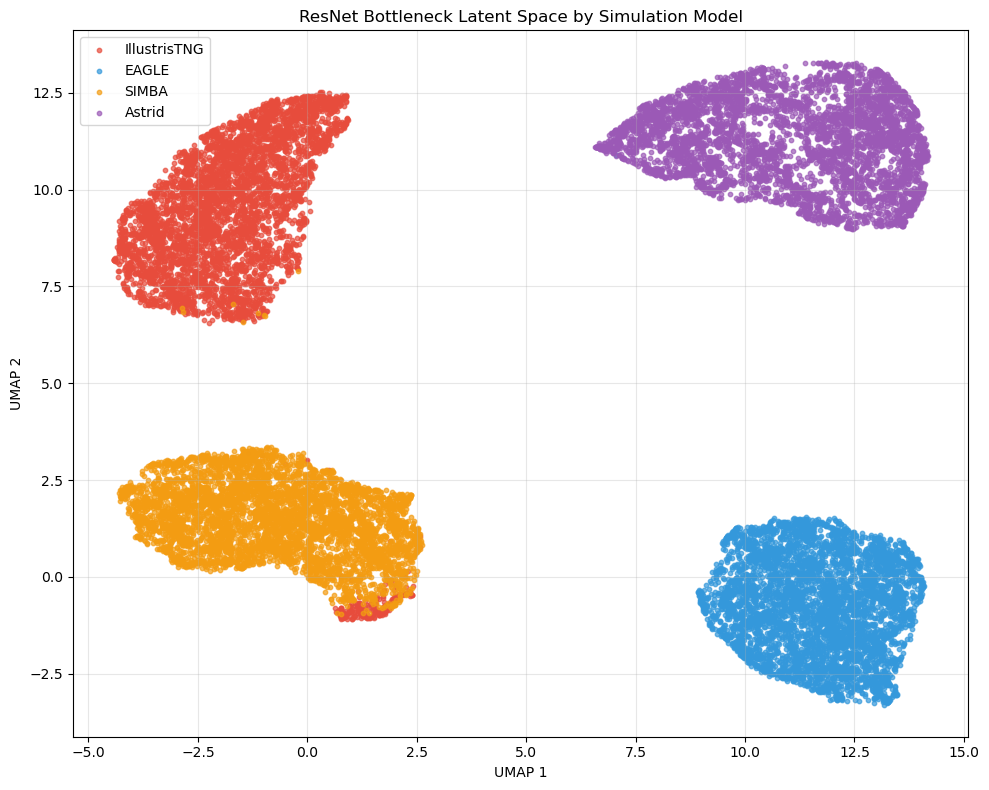

Visualization saved. Total samples: 20000


In [15]:
# checkpoint_path = 'lightning_logs/FM_all/checkpoints/best-model-epoch=88-val_loss=0.023915.ckpt'
checkpoint_path = 'lightning_logs/FM_dm_all/checkpoints/best-model-epoch=94-val_loss=0.026710.ckpt'
simulation_models = ['IllustrisTNG', 'EAGLE', 'SIMBA', 'Astrid']

print("Extracting ResNet features...")
extractor = ResNetBottleneckExtractor(checkpoint_path)

all_features_resnet = []
all_labels_resnet = []

for model_name in simulation_models:
    print(f"Processing {model_name}...")
    total_mass, star_maps, gas_maps, cosmo_params, astro_params = load_model_data(model_name, n_samples=5000)
    features = extractor.extract_features(total_mass, star_maps, gas_maps, cosmo_params)
    
    if len(features) > 0:
        all_features_resnet.append(features)
        all_labels_resnet.extend([model_name] * len(features))

# UMAP
X_resnet = np.vstack(all_features_resnet)
print(f"Total features: {X_resnet.shape}")

embedding_umap_resnet = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_resnet)

# Plot
plt.figure(figsize=(10, 8))
colors = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6']

for i, model_name in enumerate(simulation_models):
    mask = [label == model_name for label in all_labels_resnet]
    plt.scatter(embedding_umap_resnet[mask, 0], embedding_umap_resnet[mask, 1], 
               c=colors[i], label=model_name, alpha=0.7, s=10)

plt.title('ResNet Bottleneck Latent Space by Simulation Model')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("resnet_umap_visualisation_dm.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Visualization saved. Total samples: {len(embedding_umap_resnet)}")


Running PCA...
Explained variance ratio: [0.45649627 0.20917952]
Total explained variance: 0.666


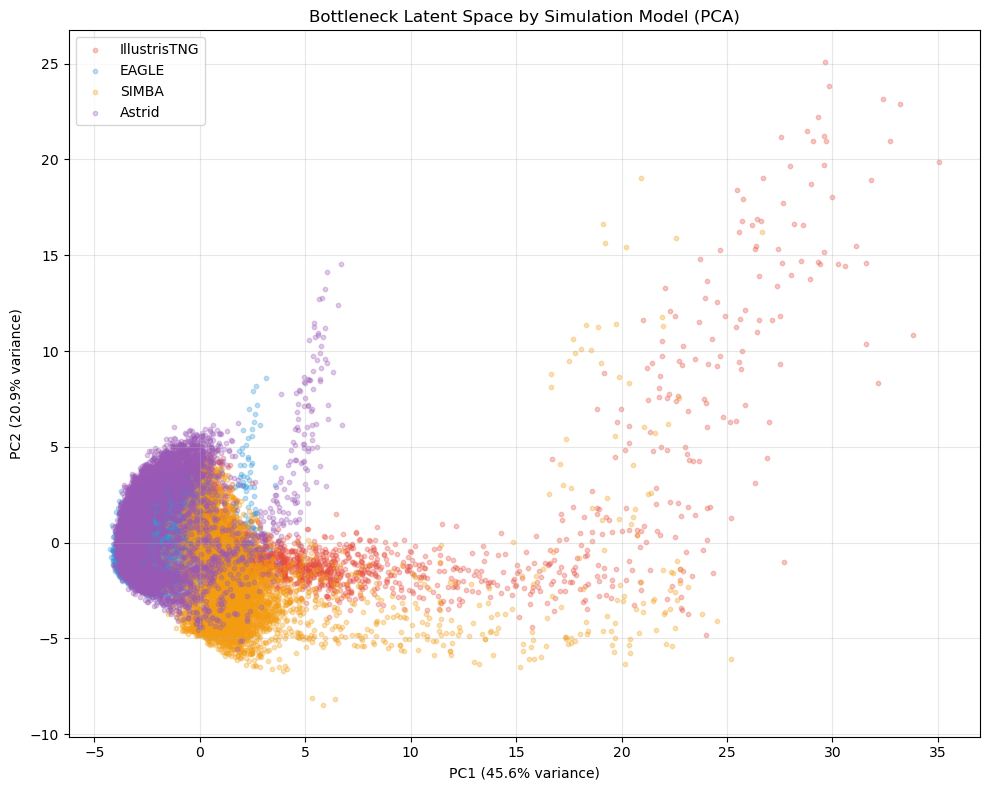

Visualization saved. Total samples: 20000


In [20]:
from sklearn.decomposition import PCA

print("Running PCA...")
stacked_features = np.vstack(all_features[:4])
pca = PCA(n_components=2, random_state=42)
embedding_pca = pca.fit_transform(stacked_features)

# Print explained variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Visualize
plt.figure(figsize=(10, 8))
for i, model_name in enumerate(simulation_models[:4]):
    mask = [label == model_name for label in all_labels[:20000]]
    plt.scatter(embedding_pca[mask, 0], embedding_pca[mask, 1], 
               c=colors[i], label=model_name, alpha=0.3, s=10)

plt.title('Bottleneck Latent Space by Simulation Model (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_visualization.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Visualization saved. Total samples: {len(embedding_pca)}")

Running 3D PCA...
Explained variance ratio: [0.45649627 0.20917952 0.07905561]
Total explained variance: 0.745


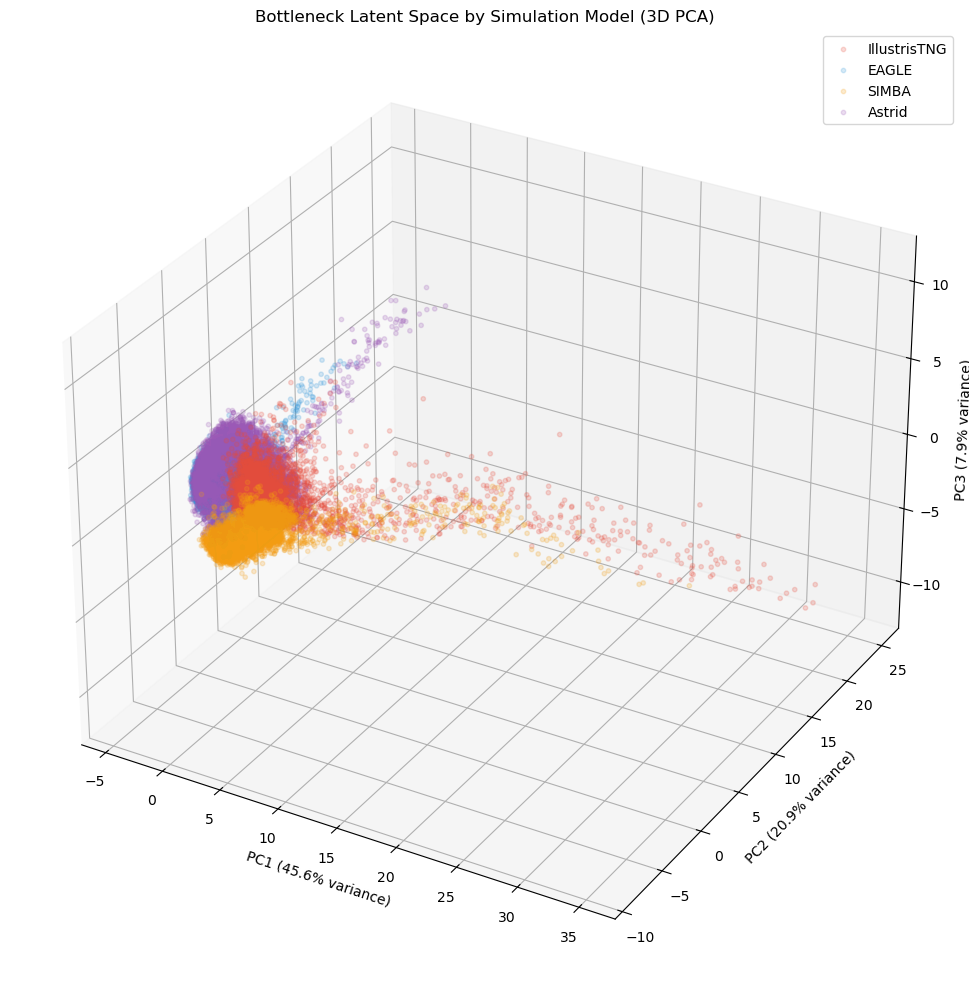

Visualization saved. Total samples: 20000


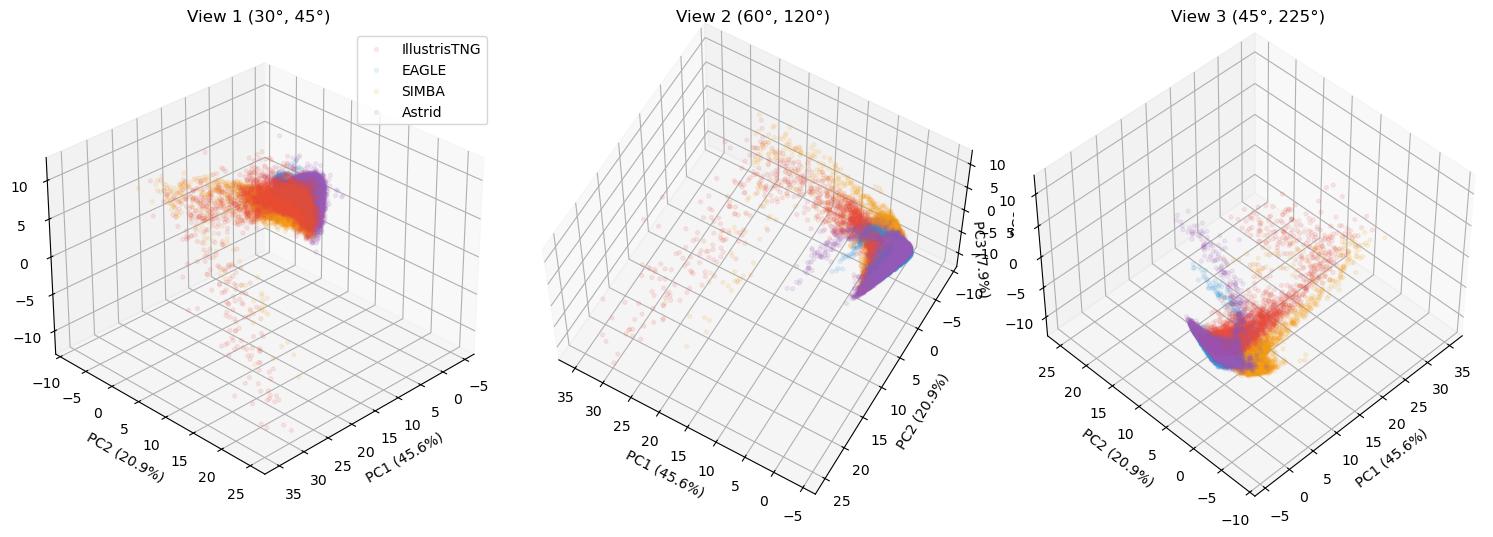

In [23]:
print("Running 3D PCA...")
pca = PCA(n_components=3, random_state=42)
stacked_features = np.vstack(all_features[:4]) # Without Magneticum
embedding_pca = pca.fit_transform(stacked_features)

# Print explained variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Create 3D visualization
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

for i, model_name in enumerate(simulation_models[:4]):
    mask = [label == model_name for label in all_labels[:20000]]
    ax.scatter(embedding_pca[mask, 0], embedding_pca[mask, 1], embedding_pca[mask, 2],
               c=colors[i], label=model_name, alpha=0.2, s=10)

ax.set_title('Bottleneck Latent Space by Simulation Model (3D PCA)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%} variance)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pca_3d_visualization.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Visualization saved. Total samples: {len(embedding_pca)}")

# Optional: Create interactive view angles
fig2 = plt.figure(figsize=(15, 5))

# Three different viewing angles
angles = [(30, 45), (60, 120), (45, 225)]
titles = ['View 1 (30°, 45°)', 'View 2 (60°, 120°)', 'View 3 (45°, 225°)']

for idx, (elev, azim) in enumerate(angles):
    ax = fig2.add_subplot(1, 3, idx+1, projection='3d')
    
    for i, model_name in enumerate(simulation_models[:4]):
        mask = [label == model_name for label in all_labels[:20000]]
        ax.scatter(embedding_pca[mask, 0], embedding_pca[mask, 1], embedding_pca[mask, 2],
                   c=colors[i], label=model_name, alpha=0.1, s=8)
    
    ax.set_title(titles[idx])
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
    ax.view_init(elev=elev, azim=azim)
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.savefig("pca_3d_multiple_views.png", dpi=300, bbox_inches='tight')
plt.show()

Running PCA...
Explained variance ratio: [0.45649627 0.20917952 0.07905561 0.0688983  0.03190501]
Total explained variance: 0.846


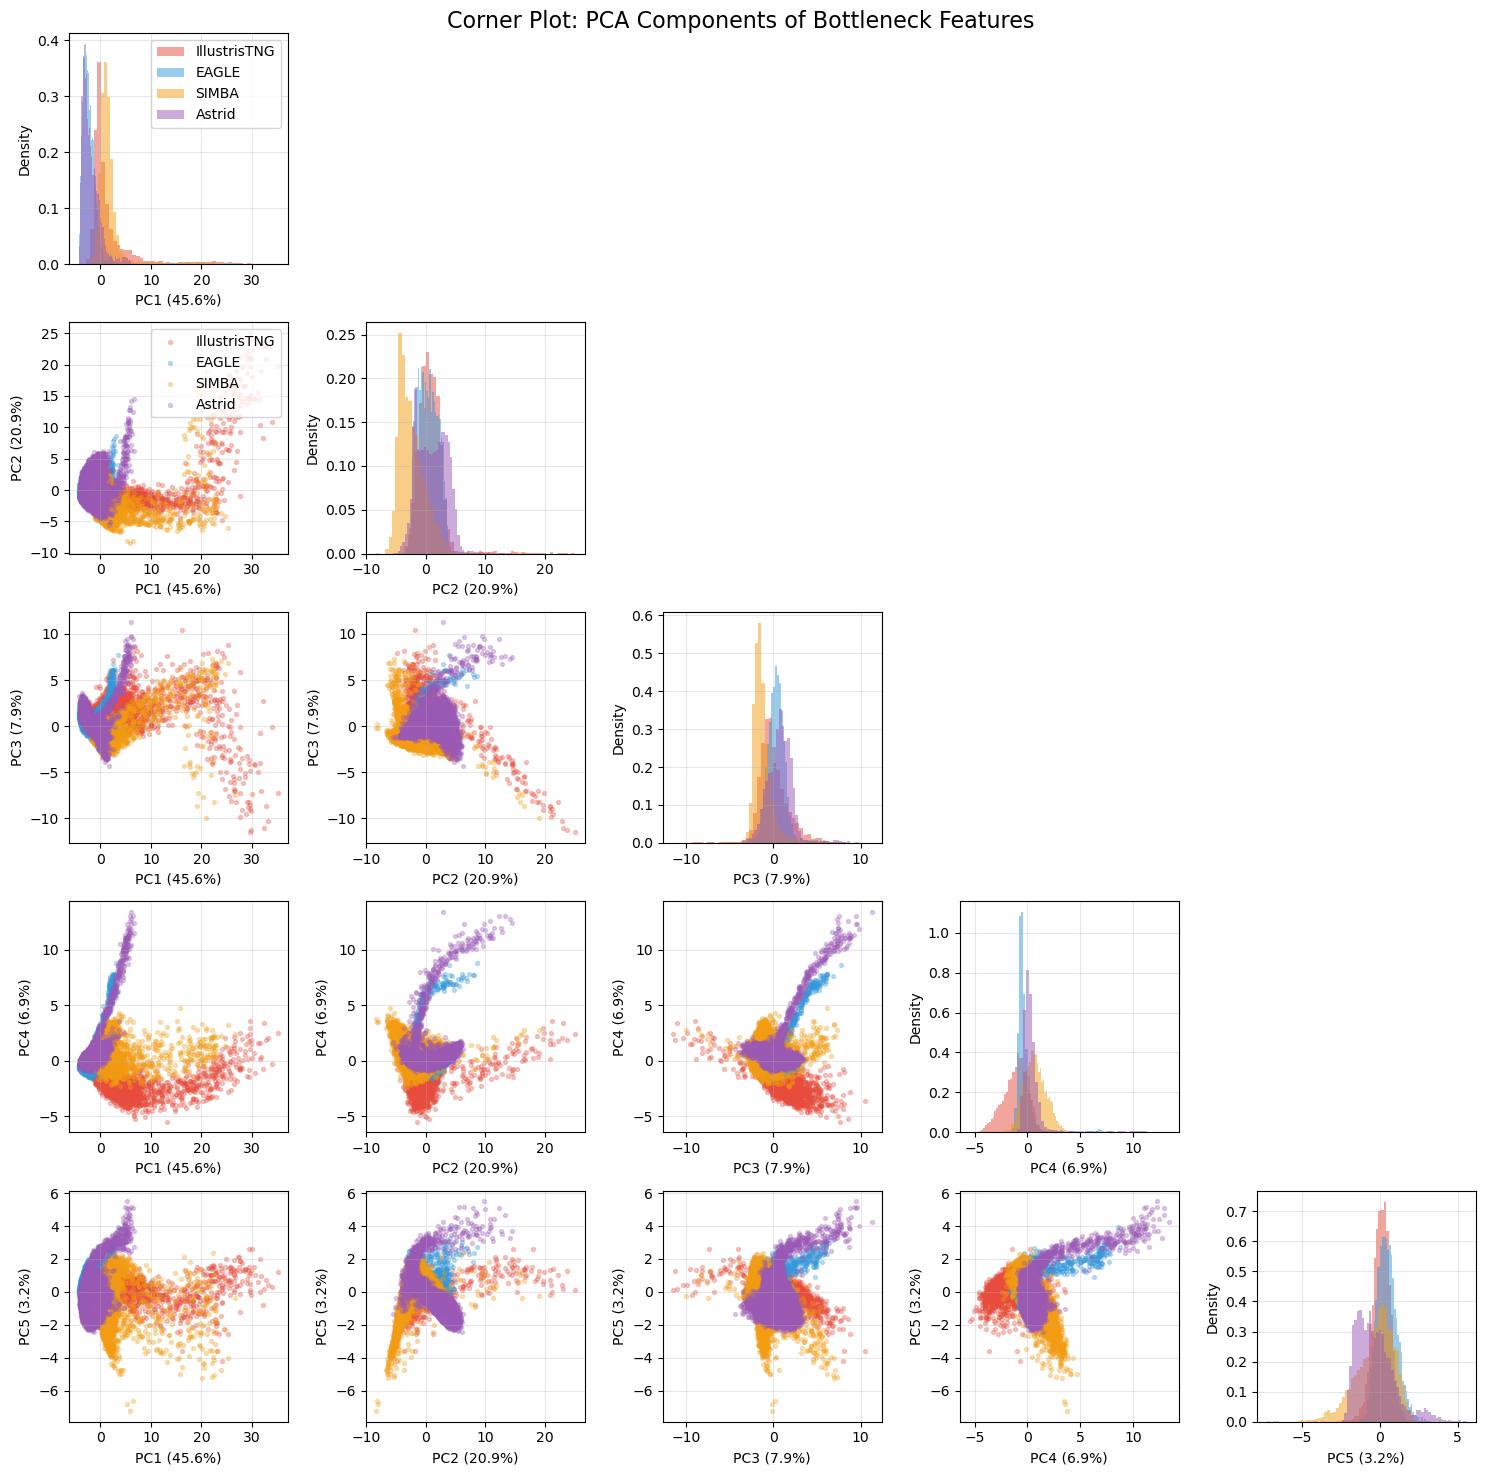


PCA Summary:
PC1 explains 45.6% of variance
PC2 explains 20.9% of variance
PC3 explains 7.9% of variance
Total explained variance: 0.846

Correlation matrix between PCs:
[[ 1.e+00 -0.e+00 -1.e-06  1.e-06  1.e-06]
 [-0.e+00  1.e+00 -1.e-06  2.e-06  1.e-06]
 [-1.e-06 -1.e-06  1.e+00  0.e+00  1.e-06]
 [ 1.e-06  2.e-06  0.e+00  1.e+00  0.e+00]
 [ 1.e-06  1.e-06  1.e-06  0.e+00  1.e+00]]
Visualization saved. Total samples: 20000


In [24]:
from sklearn.decomposition import PCA

print("Running PCA...")
N=5
stacked_features = np.vstack(all_features[:4])
pca = PCA(n_components=N, random_state=42)
embedding_pca = pca.fit_transform(stacked_features)

# Print explained variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Create corner plot
fig, axes = plt.subplots(N, N, figsize=(15, 15))

# PCA component labels with explained variance
pc_labels = [f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})' for i in range(N)]

for i, model_name in enumerate(simulation_models[:4]):
    mask = [label == model_name for label in all_labels[:20000]]
    model_data = embedding_pca[mask]
    
    # Plot pairwise scatter plots (lower triangle)
    for row in range(N):
        for col in range(N):
            ax = axes[row, col]
            
            if row > col:  # Lower triangle - scatter plots
                ax.scatter(model_data[:, col], model_data[:, row], 
                          c=colors[i], label=model_name, alpha=0.3, s=8)
                ax.set_xlabel(pc_labels[col])
                ax.set_ylabel(pc_labels[row])
                ax.grid(True, alpha=0.3)
                
            elif row == col:  # Diagonal - histograms
                ax.hist(model_data[:, row], bins=50, alpha=0.5, 
                       color=colors[i], label=model_name, density=True)
                ax.set_xlabel(pc_labels[row])
                ax.set_ylabel('Density')
                ax.grid(True, alpha=0.3)
                
            else:  # Upper triangle - remove axes
                ax.axis('off')

# Add legends
axes[0, 0].legend(loc='upper right')
axes[1, 0].legend(loc='upper right')

# Set title
fig.suptitle('Corner Plot: PCA Components of Bottleneck Features', fontsize=16)

plt.tight_layout()
plt.savefig("pca_corner_plot.png", dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nPCA Summary:")
print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]:.1%} of variance") 
print(f"PC3 explains {pca.explained_variance_ratio_[2]:.1%} of variance")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Additional: Show correlation matrix between PCs (should be zero for PCA)
print(f"\nCorrelation matrix between PCs:")
pc_corr = np.corrcoef(embedding_pca.T)
print(pc_corr.round(6))

print(f"Visualization saved. Total samples: {len(embedding_pca)}")

In [25]:
from sklearn.decomposition import PCA
from matplotlib.colors import to_rgba
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde

def estimate_2d_density(x, y, bins=50, smooth=1.0):
    """Estimate 2D density using histogram + gaussian smoothing"""
    H, xedges, yedges = np.histogram2d(x, y, bins=bins, density=True)
    H = gaussian_filter(H, sigma=smooth)
    X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
    return X, Y, H.T

def estimate_1d_density(x, bins=50, smooth=1.0):
    """Estimate 1D density using KDE"""
    try:
        kde = gaussian_kde(x)
        x_range = np.linspace(x.min(), x.max(), 200)
        density = kde(x_range)
        return x_range, density
    except:
        # Fallback to histogram if KDE fails
        counts, edges = np.histogram(x, bins=bins, density=True)
        centers = (edges[:-1] + edges[1:]) / 2
        return centers, counts
N = 5
print(f"Running PCA...{N} components")
pca = PCA(n_components=N, random_state=42)
stacked_features = np.vstack(all_features[:4])
embedding_pca = pca.fit_transform(stacked_features)
# Print explained variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")

Running PCA...5 components
Explained variance ratio: [0.45649627 0.20917952 0.07905561 0.0688983  0.03190501]
Total explained variance: 0.846


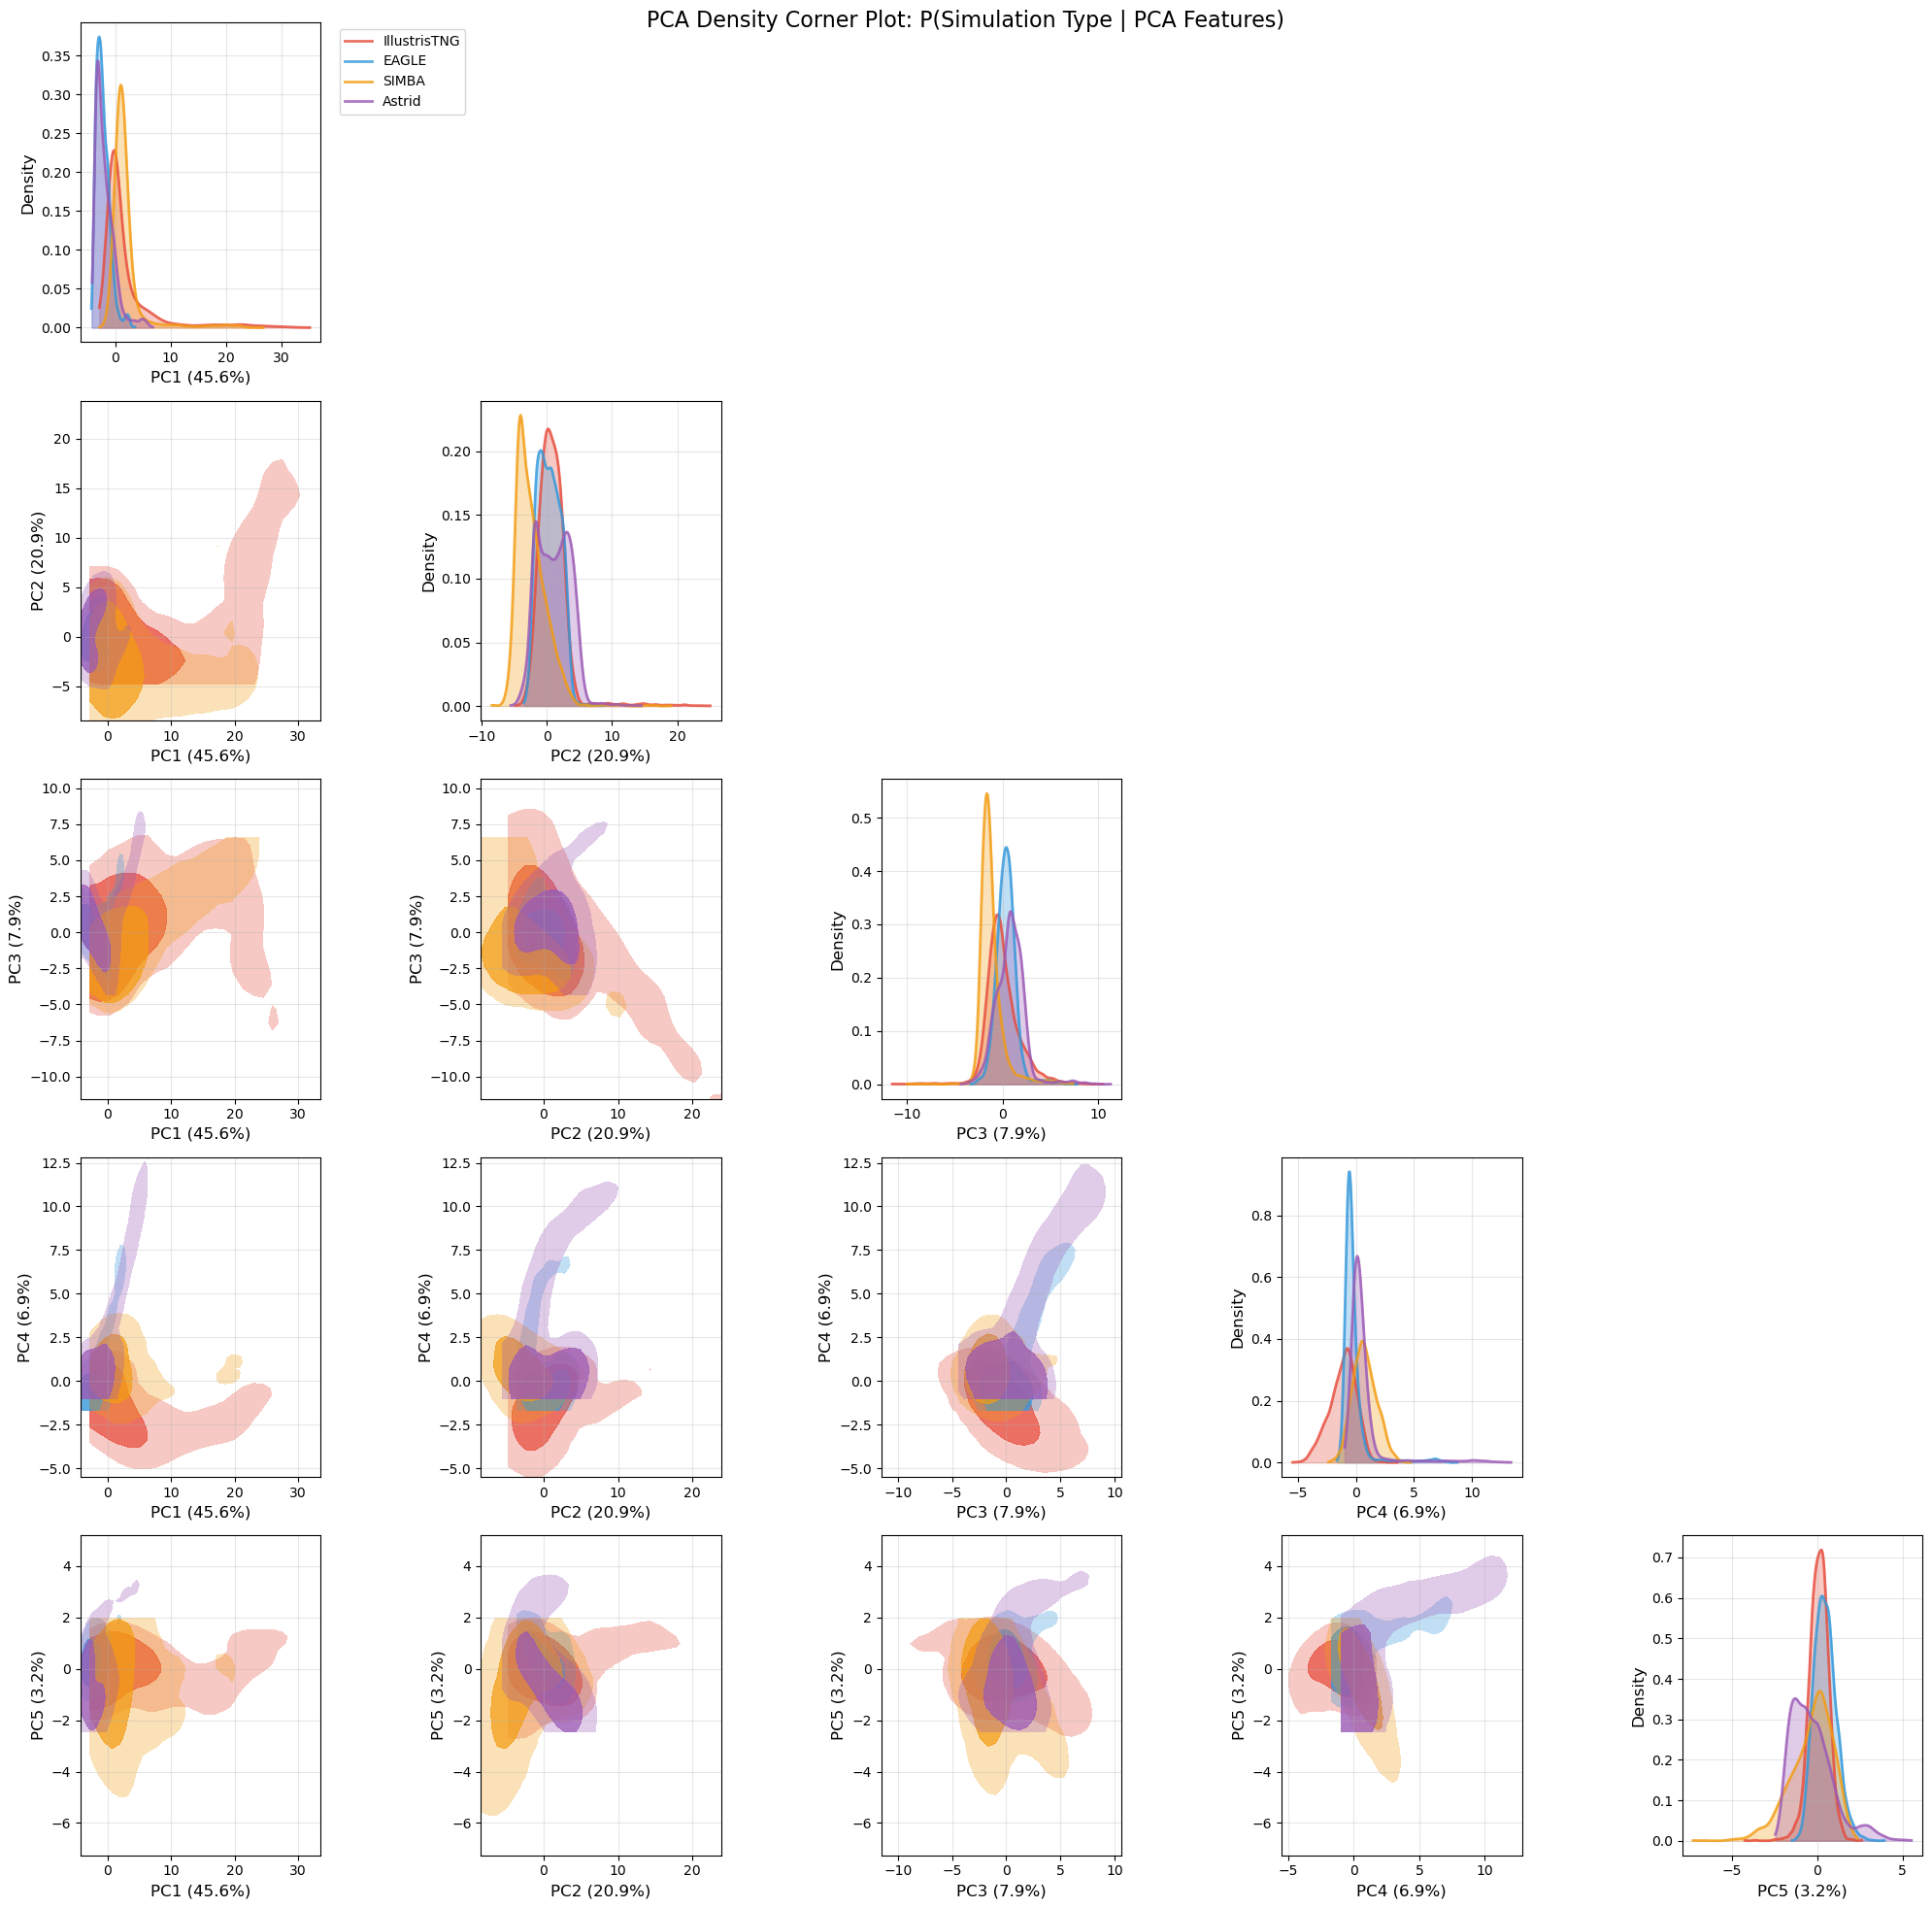


PCA Summary:
PC1 explains 45.6% of variance
PC2 explains 20.9% of variance
PC3 explains 7.9% of variance
Total explained variance: 0.846
Visualization saved. Total samples: 20000


In [27]:
# Convert labels to numpy array for easier masking
all_labels_array = np.array(all_labels[:20000])

# --- Create Density Corner Plot ---
n_components = N
fig, axes = plt.subplots(n_components, n_components, 
                        figsize=(4*n_components, 4*n_components))

# PCA component labels with explained variance
pc_labels = [f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})' for i in range(n_components)]

for i in range(n_components):
    for j in range(n_components):
        ax = axes[i, j]
        
        if i < j:  # Upper triangle - leave empty
            ax.set_visible(False)
            continue
            
        elif i == j:  # Diagonal - 1D density plots
            for model_idx, model_name in enumerate(simulation_models[:4]):
                mask = all_labels_array == model_name
                data = embedding_pca[mask, i]
                
                if len(data) > 10:  # Only plot if we have enough data
                    x_range, density = estimate_1d_density(data)
                    ax.plot(x_range, density, color=colors[model_idx], 
                           linewidth=2, alpha=0.8, label=model_name)
                    ax.fill_between(x_range, density, alpha=0.3, color=colors[model_idx])
            
            ax.set_xlabel(pc_labels[i], fontsize=12)
            ax.set_ylabel('Density', fontsize=12)
            ax.grid(True, alpha=0.3)
            
            if i == 0:  # Add legend only to first diagonal plot
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
                
        else:  # Lower triangle - 2D density contour plots
            for model_idx, model_name in enumerate(simulation_models):
                mask = all_labels_array == model_name
                x_data = embedding_pca[mask, j]  # x-axis dimension
                y_data = embedding_pca[mask, i]  # y-axis dimension
                
                if len(x_data) > 50:  # Only plot if we have enough data
                    try:
                        # Create 2D density using histogram + smoothing
                        xx, yy, density = estimate_2d_density(x_data, y_data, bins=25, smooth=1.2)

                        # Create two levels for sunny egg effect based on density percentiles
                        max_density = density.max()
                        min_density = density.min()
                        
                        # Use percentiles of the actual density values for better control
                        low_level = np.percentile(density, 70)   # 70th percentile
                        high_level = np.percentile(density, 90)  # 90th percentile
                        
                        # Ensure we have meaningful levels
                        if low_level >= high_level:
                            low_level = min_density + (max_density - min_density) * 0.5
                            high_level = min_density + (max_density - min_density) * 0.9
                        
                        levels_to_use = [low_level, high_level]

                        # Fill outer ring (lighter)
                        ax.contourf(xx, yy, density, levels=[levels_to_use[0], levels_to_use[1]], 
                                   colors=[colors[model_idx]], alpha=0.3)
                        # Fill inner core (darker)
                        ax.contourf(xx, yy, density, levels=[levels_to_use[1], max_density], 
                                   colors=[colors[model_idx]], alpha=0.8)
                                                
                    except Exception as e:
                        print(f"Could not create density plot for {model_name}: {e}")
                        # Fallback: just plot a few sample points
                        sample_idx = np.random.choice(len(x_data), min(100, len(x_data)), replace=False)
                        ax.scatter(x_data[sample_idx], y_data[sample_idx], 
                                 color=colors[model_idx], alpha=0.5, s=10, label=model_name)
            
            ax.set_xlabel(pc_labels[j], fontsize=12)
            ax.set_ylabel(pc_labels[i], fontsize=12)
            ax.grid(True, alpha=0.3)

plt.suptitle("PCA Density Corner Plot: P(Simulation Type | PCA Features)", 
             fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig('pca_density_corner_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nPCA Summary:")
print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]:.1%} of variance") 
print(f"PC3 explains {pca.explained_variance_ratio_[2]:.1%} of variance")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")
print(f"Visualization saved. Total samples: {len(embedding_pca)}")

In [5]:
TNG_features, TNG_labels, TNG_astro_params, TNG_cosmo_params = features_extraction(simulation_models=['IllustrisTNG'],
                                                                                  n_samples_per_model=15000)

Extracting bottleneck features...
Processing IllustrisTNG...
  Extracted 15000 features
  Memory cleared after IllustrisTNG
Total features: (15000, 512)


<>:174: SyntaxWarning: invalid escape sequence '\O'
<>:175: SyntaxWarning: invalid escape sequence '\O'
<>:176: SyntaxWarning: invalid escape sequence '\O'
<>:183: SyntaxWarning: invalid escape sequence '\s'
<>:184: SyntaxWarning: invalid escape sequence '\s'
<>:185: SyntaxWarning: invalid escape sequence '\s'
<>:192: SyntaxWarning: invalid escape sequence '\O'
<>:193: SyntaxWarning: invalid escape sequence '\s'
<>:174: SyntaxWarning: invalid escape sequence '\O'
<>:175: SyntaxWarning: invalid escape sequence '\O'
<>:176: SyntaxWarning: invalid escape sequence '\O'
<>:183: SyntaxWarning: invalid escape sequence '\s'
<>:184: SyntaxWarning: invalid escape sequence '\s'
<>:185: SyntaxWarning: invalid escape sequence '\s'
<>:192: SyntaxWarning: invalid escape sequence '\O'
<>:193: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4178484/1543295162.py:174: SyntaxWarning: invalid escape sequence '\O'
  axes[0, 1].set_xlabel('True $\Omega_m$')
/tmp/ipykernel_4178484/1543295162.py:17

Training on device: cuda
Input shape: (15000, 512), Output shape: (15000, 2)
Training on 12000 samples, testing on 3000 samples
------------------------------------------------------------
Epoch   0/100 | Train Loss: 0.094756 | Test Loss: 0.055488
Epoch  10/100 | Train Loss: 0.012796 | Test Loss: 0.008284
Epoch  20/100 | Train Loss: 0.007108 | Test Loss: 0.005310
Epoch  30/100 | Train Loss: 0.005617 | Test Loss: 0.004587
Epoch  40/100 | Train Loss: 0.005124 | Test Loss: 0.004316
Epoch  50/100 | Train Loss: 0.004703 | Test Loss: 0.003863
Epoch  60/100 | Train Loss: 0.004521 | Test Loss: 0.003722
Epoch  70/100 | Train Loss: 0.004367 | Test Loss: 0.003593
Epoch  80/100 | Train Loss: 0.004343 | Test Loss: 0.003409
Epoch  90/100 | Train Loss: 0.004146 | Test Loss: 0.003398
Epoch  99/100 | Train Loss: 0.004010 | Test Loss: 0.003481

FINAL EVALUATION
Parameter 0: MSE = 0.002313 | RMSE = 0.048091 | R² = 0.8247
Parameter 1: MSE = 0.004646 | RMSE = 0.068161 | R² = 0.6575
Overall:     MSE = 0.003

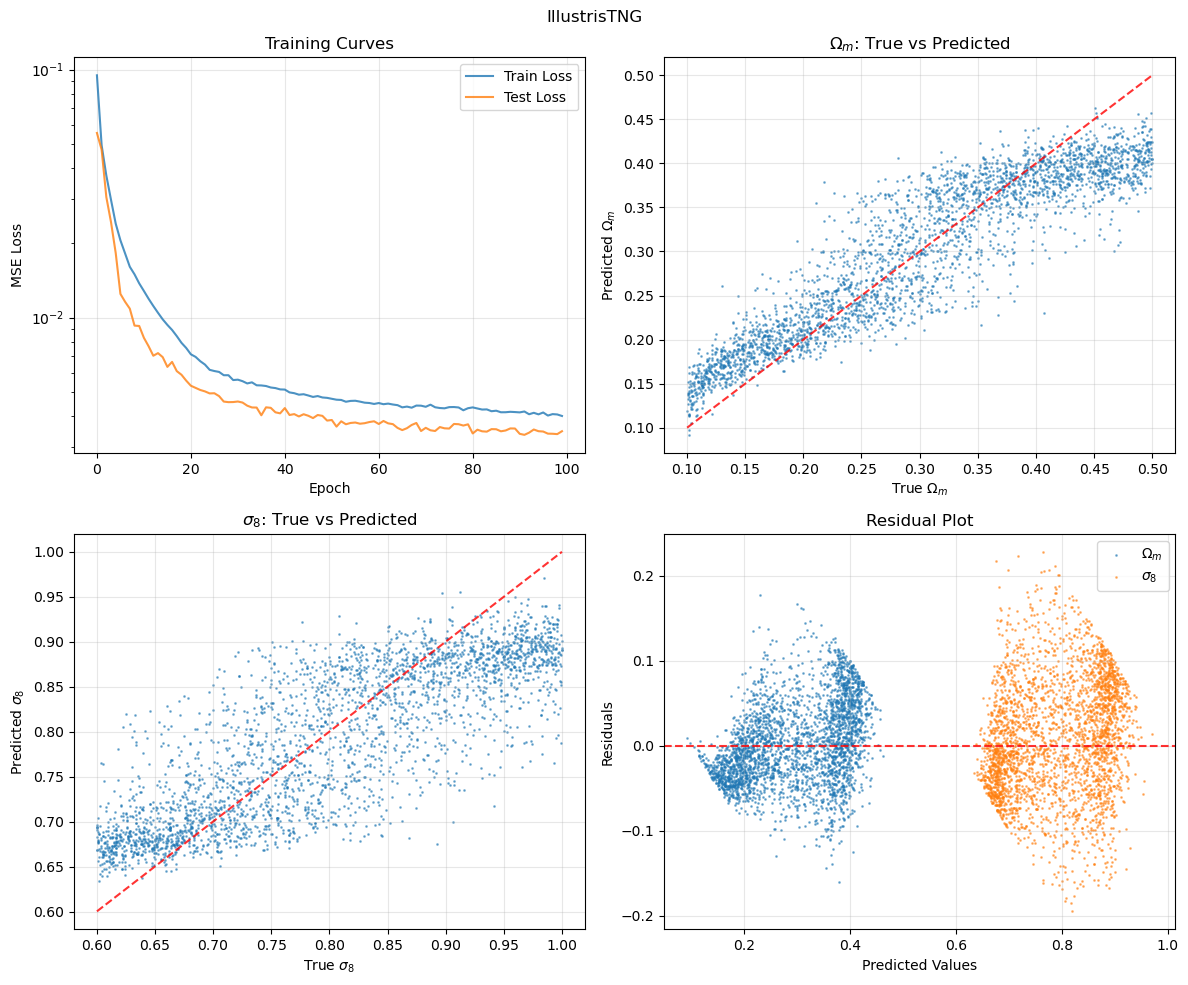

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

class SimpleMLP(nn.Module):
    def __init__(self, input_dim=512, output_dim=2, hidden_dims=[256, 128, 64]):
        super(SimpleMLP, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        # Hidden layers
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.6)
            ])
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

def train_mlp(X, y, test_size=0.2, batch_size=128, epochs=100, lr=1e-3, device=None, output_dim=2, model_name='IllustrisTNG'):
    """
    Train MLP on input features and target parameters
    
    Args:
        X: Input features (20000, 512)
        y: Target parameters (20000, 2)
        test_size: Fraction of data for testing
        batch_size: Batch size for training
        epochs: Number of training epochs
        lr: Learning rate
        device: Device to train on
    """
    
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"Training on device: {device}")
    print(f"Input shape: {X.shape}, Output shape: {y.shape}")
    
    # Normalize input features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42
    )
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train)
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.FloatTensor(y_test)
    
    # Create datasets and dataloaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize model
    model = SimpleMLP(input_dim=512, output_dim=output_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Training loop
    train_losses = []
    test_losses = []
    
    print(f"Training on {len(X_train)} samples, testing on {len(X_test)} samples")
    print("-" * 60)
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation phase
        model.eval()
        test_loss = 0.0
        
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                test_loss += loss.item()
        
        # Calculate average losses
        train_loss /= len(train_loader)
        test_loss /= len(test_loader)
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        
        # Print progress
        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")
    
    # Final evaluation
    print("\n" + "="*60)
    print("FINAL EVALUATION")
    print("="*60)
    
    model.eval()
    with torch.no_grad():
        X_test_device = X_test_tensor.to(device)
        predictions = model(X_test_device).cpu().numpy()
    
    # Calculate metrics for each parameter
    for i in range(y_test.shape[1]):
        mse = mean_squared_error(y_test[:, i], predictions[:, i])
        r2 = r2_score(y_test[:, i], predictions[:, i])
        rmse = np.sqrt(mse)
        print(f"Parameter {i}: MSE = {mse:.6f} | RMSE = {rmse:.6f} | R² = {r2:.4f}")
    
    # Overall metrics
    overall_mse = mean_squared_error(y_test, predictions)
    overall_r2 = r2_score(y_test, predictions)
    overall_rmse = np.sqrt(overall_mse)
    print(f"Overall:     MSE = {overall_mse:.6f} | RMSE = {overall_rmse:.6f} | R² = {overall_r2:.4f}")
    
    # Plot results
    plot_results(train_losses, test_losses, y_test, predictions, model_name)
    
    return model, scaler, train_losses, test_losses, predictions

def plot_results(train_losses, test_losses, y_true, y_pred, model_name):
    """Plot training curves and prediction results"""
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Training curves
    axes[0, 0].plot(train_losses, label='Train Loss', alpha=0.8)
    axes[0, 0].plot(test_losses, label='Test Loss', alpha=0.8)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('MSE Loss')
    axes[0, 0].set_title('Training Curves')
    axes[0, 0].legend()
    axes[0, 0].set_yscale('log')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Parameter 0 predictions
    axes[0, 1].scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 0].min(), y_true[:, 0].max()
    axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[0, 1].set_xlabel('True $\Omega_m$')
    axes[0, 1].set_ylabel('Predicted $\Omega_m$')
    axes[0, 1].set_title('$\Omega_m$: True vs Predicted')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Parameter 1 predictions
    axes[1, 0].scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 1].min(), y_true[:, 1].max()
    axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[1, 0].set_xlabel('True $\sigma_8$')
    axes[1, 0].set_ylabel('Predicted $\sigma_8$')
    axes[1, 0].set_title('$\sigma_8$: True vs Predicted')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Residuals
    residuals_0 = y_true[:, 0] - y_pred[:, 0]
    residuals_1 = y_true[:, 1] - y_pred[:, 1]
    
    axes[1, 1].scatter(y_pred[:, 0], residuals_0, alpha=0.5, s=1, label='$\Omega_m$')
    axes[1, 1].scatter(y_pred[:, 1], residuals_1, alpha=0.5, s=1, label='$\sigma_8$')
    axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.8)
    axes[1, 1].set_xlabel('Predicted Values')
    axes[1, 1].set_ylabel('Residuals')
    axes[1, 1].set_title('Residual Plot')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(model_name)
    plt.tight_layout()
    plt.savefig('p(cosmo|zbar).png')
    plt.show()

def predict_parameters(model, scaler, X_new, device=None):
    """Make predictions on new data"""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model.eval()
    X_scaled = scaler.transform(X_new)
    X_tensor = torch.FloatTensor(X_scaled).to(device)
    
    with torch.no_grad():
        predictions = model(X_tensor).cpu().numpy()
    
    return predictions

# Train the model
model, scaler, train_losses, test_losses, predictions = train_mlp(np.asarray(TNG_features[0]), 
                                                                  np.asarray(TNG_cosmo_params[0]),
                                                                  model_name='IllustrisTNG')

# Make predictions on new data
# new_predictions = predict_parameters(model, scaler, np.asarray(all_features[0]))


Training on device: cuda
Input shape: (15000, 512), Output shape: (15000, 4)
Training on 12000 samples, testing on 3000 samples
------------------------------------------------------------
Epoch   0/100 | Train Loss: 0.258397 | Test Loss: 0.143155
Epoch  10/100 | Train Loss: 0.093212 | Test Loss: 0.082281
Epoch  20/100 | Train Loss: 0.078995 | Test Loss: 0.073677
Epoch  30/100 | Train Loss: 0.072855 | Test Loss: 0.069848
Epoch  40/100 | Train Loss: 0.071315 | Test Loss: 0.070145
Epoch  50/100 | Train Loss: 0.070257 | Test Loss: 0.069086
Epoch  60/100 | Train Loss: 0.069313 | Test Loss: 0.067837
Epoch  70/100 | Train Loss: 0.068326 | Test Loss: 0.068844
Epoch  80/100 | Train Loss: 0.067532 | Test Loss: 0.069317
Epoch  90/100 | Train Loss: 0.066359 | Test Loss: 0.068803
Epoch  99/100 | Train Loss: 0.065253 | Test Loss: 0.068791

FINAL EVALUATION
Parameter 0: MSE = 0.059252 | RMSE = 0.243416 | R² = 0.6383
Parameter 1: MSE = 0.160461 | RMSE = 0.400576 | R² = 0.0118
Parameter 2: MSE = 0.019

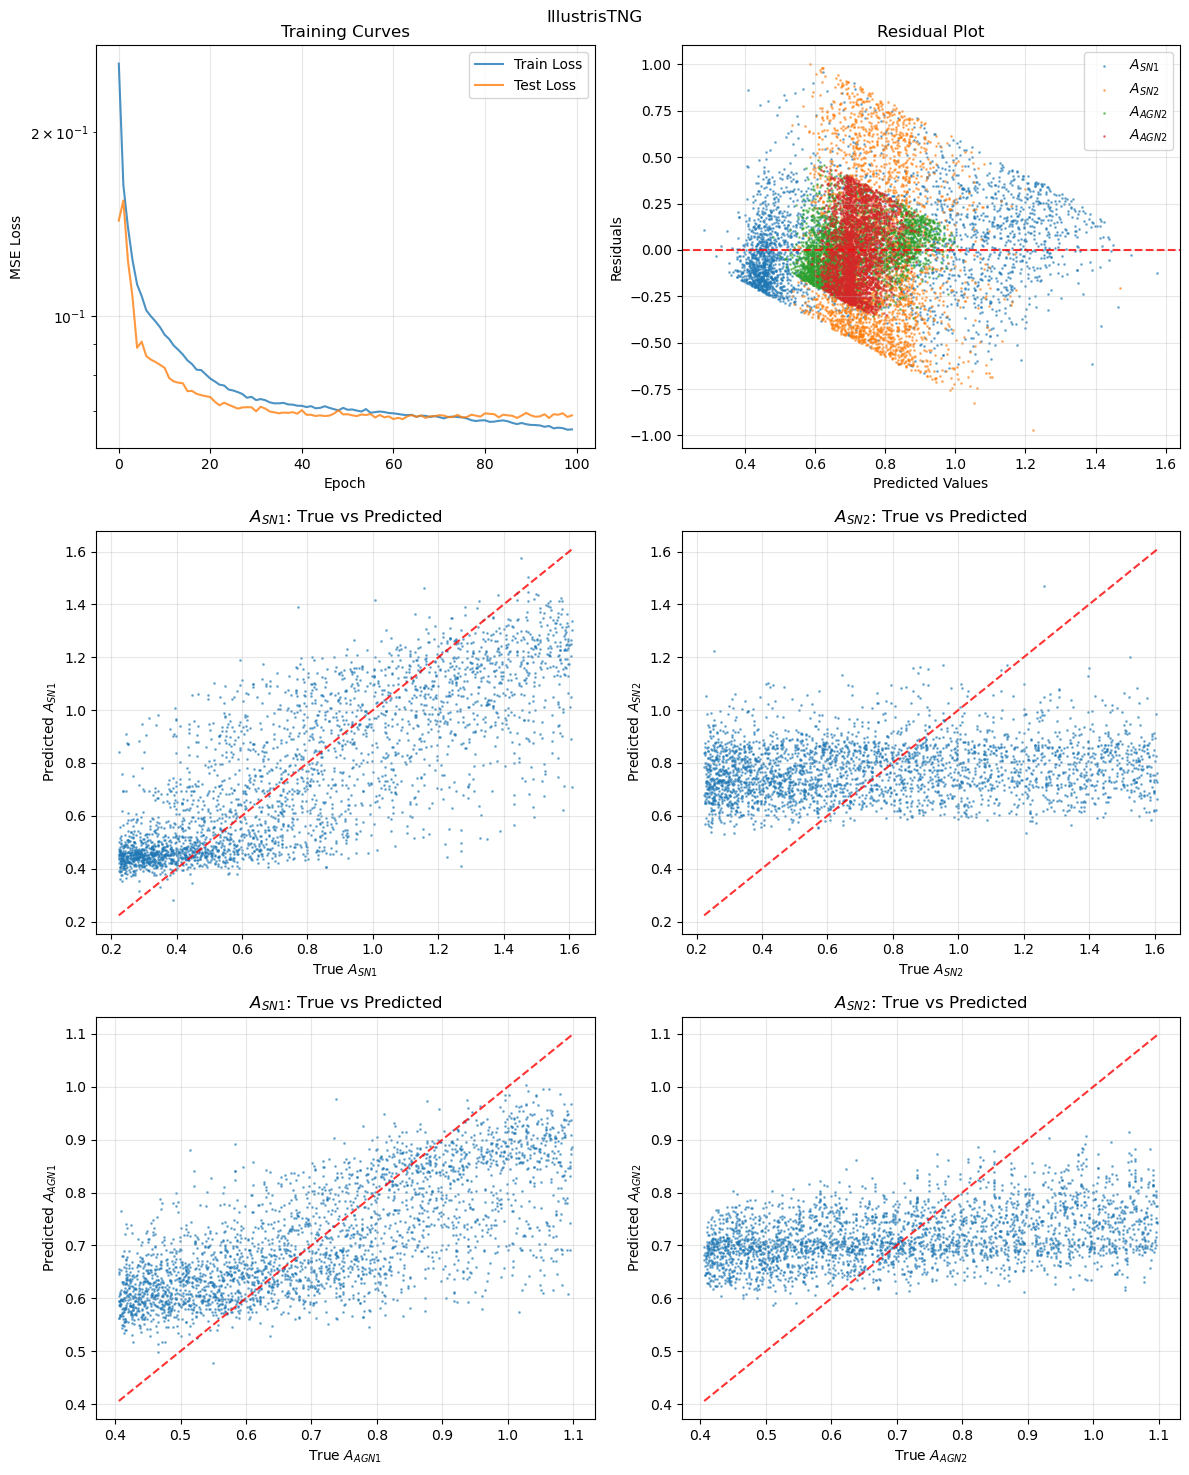

In [11]:
def plot_results(train_losses, test_losses, y_true, y_pred, model_name):
    """Plot training curves and prediction results"""
    
    fig, axes = plt.subplots(3, 2, figsize=(12, 15))
    
    # Training curves
    axes[0, 0].plot(train_losses, label='Train Loss', alpha=0.8)
    axes[0, 0].plot(test_losses, label='Test Loss', alpha=0.8)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('MSE Loss')
    axes[0, 0].set_title('Training Curves')
    axes[0, 0].legend()
    axes[0, 0].set_yscale('log')
    axes[0, 0].grid(True, alpha=0.3)

    # Residuals
    residuals_0 = y_true[:, 0] - y_pred[:, 0]
    residuals_1 = y_true[:, 1] - y_pred[:, 1]
    residuals_2 = y_true[:, 2] - y_pred[:, 2]
    residuals_3 = y_true[:, 3] - y_pred[:, 3]
    
    axes[0, 1].scatter(y_pred[:, 0], residuals_0, alpha=0.5, s=1, label='$A_{SN1}$')
    axes[0, 1].scatter(y_pred[:, 1], residuals_1, alpha=0.5, s=1, label='$A_{SN2}$')
    axes[0, 1].scatter(y_pred[:, 2], residuals_2, alpha=0.5, s=1, label='$A_{AGN2}$')
    axes[0, 1].scatter(y_pred[:, 3], residuals_3, alpha=0.5, s=1, label='$A_{AGN2}$')
    axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.8)
    axes[0, 1].set_xlabel('Predicted Values')
    axes[0, 1].set_ylabel('Residuals')
    axes[0, 1].set_title('Residual Plot')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Parameter 0 predictions
    axes[1, 0].scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 0].min(), y_true[:, 0].max()
    axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[1, 0].set_xlabel('True $A_{SN1}$')
    axes[1, 0].set_ylabel('Predicted $A_{SN1}$')
    axes[1, 0].set_title('$A_{SN1}$: True vs Predicted')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Parameter 1 predictions
    axes[1, 1].scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 1].min(), y_true[:, 1].max()
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[1, 1].set_xlabel('True $A_{SN2}$')
    axes[1, 1].set_ylabel('Predicted $A_{SN2}$')
    axes[1, 1].set_title('$A_{SN2}$: True vs Predicted')
    axes[1, 1].grid(True, alpha=0.3)

    # Parameter 3 predictions
    axes[2, 0].scatter(y_true[:, 2], y_pred[:, 2], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 2].min(), y_true[:, 2].max()
    axes[2, 0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[2, 0].set_xlabel('True $A_{AGN1}$')
    axes[2, 0].set_ylabel('Predicted $A_{AGN1}$')
    axes[2, 0].set_title('$A_{SN1}$: True vs Predicted')
    axes[2, 0].grid(True, alpha=0.3)
    
    # Parameter 4 predictions
    axes[2, 1].scatter(y_true[:, 3], y_pred[:, 3], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 3].min(), y_true[:, 3].max()
    axes[2, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[2, 1].set_xlabel('True $A_{AGN2}$')
    axes[2, 1].set_ylabel('Predicted $A_{AGN2}$')
    axes[2, 1].set_title('$A_{SN2}$: True vs Predicted')
    axes[2, 1].grid(True, alpha=0.3)
    
    plt.suptitle(model_name)
    plt.tight_layout()
    plt.savefig('p(astro|zbar).png')
    plt.show()

def predict_parameters(model, scaler, X_new, device=None):
    """Make predictions on new data"""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model.eval()
    X_scaled = scaler.transform(X_new)
    X_tensor = torch.FloatTensor(X_scaled).to(device)
    
    with torch.no_grad():
        predictions = model(X_tensor).cpu().numpy()
    
    return predictions

# Train the model
model, scaler, train_losses, test_losses, predictions = train_mlp(TNG_features[0], np.log1p(TNG_astro_params[0]), epochs=100, output_dim=4)

# Make predictions on new data
# new_predictions = predict_parameters(model, scaler, X)


Training on device: cuda
Input shape: (15000, 512), Output shape: (15000, 2)
Training on 12000 samples, testing on 3000 samples
------------------------------------------------------------
Epoch   0/200 | Train Loss: 0.345373 | Test Loss: 0.276421
Epoch  10/200 | Train Loss: 0.191026 | Test Loss: 0.172032
Epoch  20/200 | Train Loss: 0.166006 | Test Loss: 0.154423
Epoch  30/200 | Train Loss: 0.154530 | Test Loss: 0.147574
Epoch  40/200 | Train Loss: 0.145491 | Test Loss: 0.146784
Epoch  50/200 | Train Loss: 0.139767 | Test Loss: 0.146128
Epoch  60/200 | Train Loss: 0.136038 | Test Loss: 0.141138
Epoch  70/200 | Train Loss: 0.131256 | Test Loss: 0.143308
Epoch  80/200 | Train Loss: 0.126129 | Test Loss: 0.141465
Epoch  90/200 | Train Loss: 0.123251 | Test Loss: 0.138846
Epoch 100/200 | Train Loss: 0.121863 | Test Loss: 0.141490
Epoch 110/200 | Train Loss: 0.117784 | Test Loss: 0.135674
Epoch 120/200 | Train Loss: 0.115850 | Test Loss: 0.137316
Epoch 130/200 | Train Loss: 0.113819 | Test 

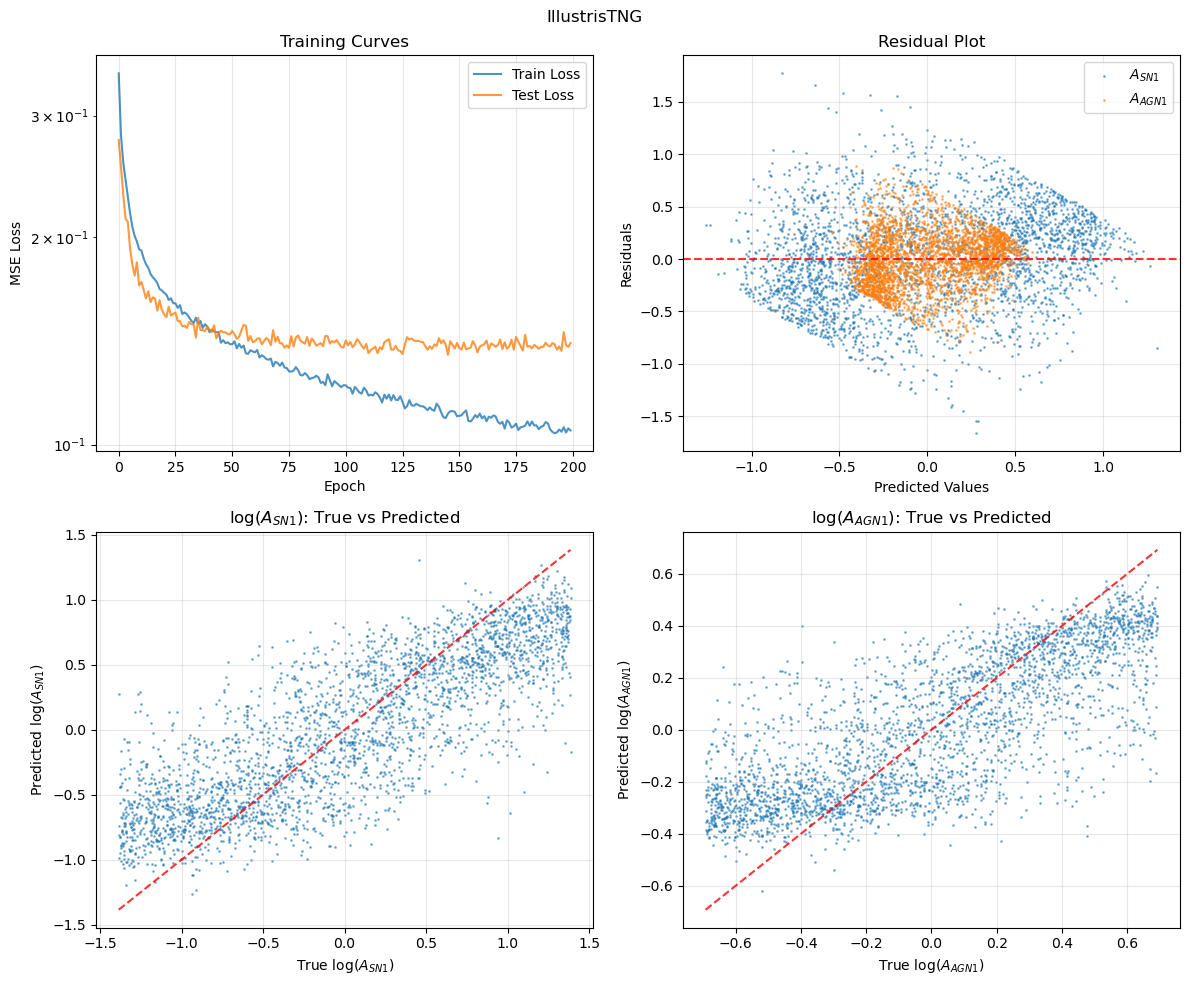

In [12]:
def plot_results(train_losses, test_losses, y_true, y_pred, model_name):
    """Plot training curves and prediction results"""
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Training curves
    axes[0, 0].plot(train_losses, label='Train Loss', alpha=0.8)
    axes[0, 0].plot(test_losses, label='Test Loss', alpha=0.8)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('MSE Loss')
    axes[0, 0].set_title('Training Curves')
    axes[0, 0].legend()
    axes[0, 0].set_yscale('log')
    axes[0, 0].grid(True, alpha=0.3)

    # Residuals
    residuals_0 = y_true[:, 0] - y_pred[:, 0]
    residuals_1 = y_true[:, 1] - y_pred[:, 1]
    
    axes[0, 1].scatter(y_pred[:, 0], residuals_0, alpha=0.5, s=1, label='$A_{SN1}$')
    axes[0, 1].scatter(y_pred[:, 1], residuals_1, alpha=0.5, s=1, label='$A_{AGN1}$')
    axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.8)
    axes[0, 1].set_xlabel('Predicted Values')
    axes[0, 1].set_ylabel('Residuals')
    axes[0, 1].set_title('Residual Plot')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Parameter 0 predictions
    axes[1, 0].scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 0].min(), y_true[:, 0].max()
    axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[1, 0].set_xlabel('True log($A_{SN1}$)')
    axes[1, 0].set_ylabel('Predicted log($A_{SN1}$)')
    axes[1, 0].set_title('log($A_{SN1}$): True vs Predicted')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Parameter 1 predictions
    axes[1, 1].scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5, s=1)
    min_val, max_val = y_true[:, 1].min(), y_true[:, 1].max()
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[1, 1].set_xlabel('True log($A_{AGN1}$)')
    axes[1, 1].set_ylabel('Predicted log($A_{AGN1}$)')
    axes[1, 1].set_title('log($A_{AGN1}$): True vs Predicted')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(model_name)
    plt.tight_layout()
    plt.savefig('p(astro|zbar).png')
    plt.show()

def predict_parameters(model, scaler, X_new, device=None):
    """Make predictions on new data"""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model.eval()
    X_scaled = scaler.transform(X_new)
    X_tensor = torch.FloatTensor(X_scaled).to(device)
    
    with torch.no_grad():
        predictions = model(X_tensor).cpu().numpy()
    
    return predictions

# Train the model
model, scaler, train_losses, test_losses, predictions = train_mlp(np.asarray(TNG_features[0]), np.log(np.asarray(TNG_astro_params[0])[:,[0,2]]), 
                                                                  model_name = 'IllustrisTNG', epochs=200, output_dim=2)



In [ ]:
# Quick diagnosis of your current model
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

def quick_diagnosis(X, y, predictions):
    """Quick check to see what's wrong with the model"""
    
    print("QUICK DIAGNOSIS")
    print("="*50)
    
    # 1. Check if model is just predicting mean
    print("1. PREDICTION VARIABILITY:")
    for i in range(y.shape[1]):
        pred_std = np.std(predictions[:, i])
        true_std = np.std(y[:, i])
        pred_mean = np.mean(predictions[:, i])
        true_mean = np.mean(y[:, i])
        
        print(f"Parameter {i}:")
        print(f"  True std: {true_std:.6f}, Pred std: {pred_std:.6f}")
        print(f"  Ratio (pred/true): {pred_std/true_std:.3f}")
        print(f"  True mean: {true_mean:.6f}, Pred mean: {pred_mean:.6f}")
        
        if pred_std/true_std < 0.1:
            print(f"  ❌ PROBLEM: Model barely varies predictions!")
        else:
            print(f"  ✅ OK: Model shows variation")
    
    # 2. Check data quality
    print("\n2. DATA QUALITY:")
    print(f"Input shape: {X.shape}")
    print(f"Output shape: {y.shape}")
    print(f"Any NaN in X: {np.isnan(X).any()}")
    print(f"Any NaN in y: {np.isnan(y).any()}")
    print(f"Any Inf in X: {np.isinf(X).any()}")
    print(f"Any Inf in y: {np.isinf(y).any()}")
    
    # Check output ranges
    print(f"\nOutput ranges:")
    for i in range(y.shape[1]):
        print(f"  Parameter {i}: [{np.min(y[:, i]):.6f}, {np.max(y[:, i]):.6f}]")
    
    # 3. Linear regression baseline
    print("\n3. LINEAR REGRESSION BASELINE:")
    try:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        lr = LinearRegression()
        lr.fit(X_scaled, y)
        lr_score = lr.score(X_scaled, y)
        lr_pred = lr.predict(X_scaled)
        
        print(f"Linear regression R²: {lr_score:.4f}")
        
        if lr_score > 0.5:
            print("✅ Linear regression works well - your NN should do better!")
        elif lr_score > 0.1:
            print("⚠️  Linear regression shows weak signal - check data")
        else:
            print("❌ Linear regression fails - major data issues")
            
        # Check if linear regression also just predicts mean
        for i in range(y.shape[1]):
            lr_std = np.std(lr_pred[:, i])
            true_std = np.std(y[:, i])
            print(f"  LR Parameter {i} std ratio: {lr_std/true_std:.3f}")
            
    except Exception as e:
        print(f"Linear regression failed: {e}")
    
    return lr_score if 'lr_score' in locals() else None

# Run this with your data:
# lr_score = quick_diagnosis(X[:5000], all_astro_params[:5000], predictions)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

class FixedMLP(nn.Module):
    def __init__(self, input_dim=512, output_dim=4, hidden_dims=[256, 128, 64]):
        super(FixedMLP, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        # Input layer
        layers.extend([
            nn.Linear(prev_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(0.2)  # Much lower dropout!
        ])
        prev_dim = hidden_dims[0]
        
        # Hidden layers
        for hidden_dim in hidden_dims[1:]:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.1)  # Even lower for deeper layers
            ])
            prev_dim = hidden_dim
        
        # Output layer - NO DROPOUT
        layers.append(nn.Linear(prev_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
        
        # Better weight initialization
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            # Xavier/Glorot initialization
            nn.init.xavier_normal_(module.weight)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
    
    def forward(self, x):
        return self.network(x)

def fixed_train_mlp(X, y, test_size=0.2, batch_size=64, epochs=300, lr=1e-3, device=None):
    """
    Fixed training function that should actually learn
    """
    
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"Training on device: {device}")
    print(f"Input shape: {X.shape}, Output shape: {y.shape}")
    
    # CRITICAL: Don't use log transform unless you know it's needed!
    # Let's use the raw targets first
    print("Using RAW targets (no log transform)")
    y_to_use = y.copy()
    
    # Better scaling
    input_scaler = StandardScaler()
    output_scaler = StandardScaler()  # Scale outputs too!
    
    X_scaled = input_scaler.fit_transform(X)
    y_scaled = output_scaler.fit_transform(y_to_use)
    
    print(f"Input stats after scaling: mean={np.mean(X_scaled):.3f}, std={np.std(X_scaled):.3f}")
    print(f"Output stats after scaling: mean={np.mean(y_scaled):.3f}, std={np.std(y_scaled):.3f}")
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_scaled, test_size=test_size, random_state=42
    )
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    y_train_tensor = torch.FloatTensor(y_train).to(device)
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    y_test_tensor = torch.FloatTensor(y_test).to(device)
    
    # Create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize model with better architecture
    model = FixedMLP(input_dim=X.shape[1], output_dim=y.shape[1], 
                     hidden_dims=[512, 256, 128]).to(device)  # Bigger network
    
    # Better loss and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)  # Lower weight decay
    
    # Better scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.8, patience=20, verbose=True
    )
    
    # Training loop with monitoring
    train_losses = []
    test_losses = []
    best_test_loss = float('inf')
    patience_counter = 0
    
    print(f"Training on {len(X_train)} samples, testing on {len(X_test)} samples")
    print("-" * 60)
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
        
        # Validation phase
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor).item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        
        # Learning rate scheduling
        scheduler.step(test_loss)
        
        # Early stopping
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        # Print progress
        if epoch % 25 == 0 or epoch == epochs - 1:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:3d}/{epochs} | Train: {train_loss:.6f} | "
                  f"Test: {test_loss:.6f} | LR: {current_lr:.1e}")
        
        # Early stopping
        if patience_counter >= 50:
            print(f"Early stopping at epoch {epoch}")
            break
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    # Final evaluation
    print("\n" + "="*60)
    print("FINAL EVALUATION")
    print("="*60)
    
    model.eval()
    with torch.no_grad():
        predictions_scaled = model(X_test_tensor).cpu().numpy()
    
    # Transform back to original scale
    predictions = output_scaler.inverse_transform(predictions_scaled)
    y_test_original = output_scaler.inverse_transform(y_test)
    
    # Calculate metrics
    param_names = ['A_SN1', 'A_SN2', 'A_AGN1', 'A_AGN2']
    
    print("Per-parameter metrics:")
    for i, name in enumerate(param_names):
        mse = mean_squared_error(y_test_original[:, i], predictions[:, i])
        r2 = r2_score(y_test_original[:, i], predictions[:, i])
        rmse = np.sqrt(mse)
        
        # Check prediction variability
        pred_std = np.std(predictions[:, i])
        true_std = np.std(y_test_original[:, i])
        
        print(f"{name}: MSE={mse:.6f} | R²={r2:.4f} | RMSE={rmse:.6f}")
        print(f"       Pred_std/True_std = {pred_std/true_std:.3f}")
        
        if pred_std/true_std < 0.1:
            print(f"       ❌ WARNING: Model not varying predictions for {name}!")
        elif r2 > 0.5:
            print(f"       ✅ Good performance for {name}")
        elif r2 > 0.1:
            print(f"       ⚠️  Weak but learning {name}")
        else:
            print(f"       ❌ Poor performance for {name}")
    
    # Overall metrics
    overall_r2 = r2_score(y_test_original, predictions)
    print(f"\nOverall R²: {overall_r2:.4f}")
    
    # Create diagnostic plots
    create_diagnostic_plots(y_test_original, predictions, param_names)
    
    return model, input_scaler, output_scaler, train_losses, test_losses, predictions, y_test_original

def create_diagnostic_plots(y_test, predictions, param_names):
    """Create diagnostic plots to see what's happening"""
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for i, name in enumerate(param_names):
        # True vs Predicted
        axes[0, i].scatter(y_test[:, i], predictions[:, i], alpha=0.6, s=10)
        min_val = min(y_test[:, i].min(), predictions[:, i].min())
        max_val = max(y_test[:, i].max(), predictions[:, i].max())
        axes[0, i].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
        axes[0, i].set_xlabel(f'True {name}')
        axes[0, i].set_ylabel(f'Predicted {name}')
        axes[0, i].set_title(f'{name}: True vs Predicted')
        axes[0, i].grid(True, alpha=0.3)
        
        # Add R² to plot
        r2 = r2_score(y_test[:, i], predictions[:, i])
        axes[0, i].text(0.05, 0.95, f'R² = {r2:.3f}', transform=axes[0, i].transAxes, 
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Prediction distribution
        axes[1, i].hist(predictions[:, i], bins=30, alpha=0.7, label='Predicted', density=True)
        axes[1, i].hist(y_test[:, i], bins=30, alpha=0.7, label='True', density=True)
        axes[1, i].set_xlabel(name)
        axes[1, i].set_ylabel('Density')
        axes[1, i].set_title(f'{name}: Distribution Comparison')
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('fixed_model_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()

# Usage:
# First run the diagnosis:
lr_score = quick_diagnosis(X[:5000], all_astro_params[:5000], predictions)

# Then train the fixed model:
model, input_scaler, output_scaler, train_losses, test_losses, predictions, y_test = fixed_train_mlp(
    X[:5000], all_astro_params[:5000], epochs=300, batch_size=64, lr=1e-3
)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class SimpleMLP(nn.Module):
    def __init__(self, input_dim=512, output_dim=2, hidden_dims=[256, 128, 64]):
        super(SimpleMLP, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        # Hidden layers
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.6)
            ])
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

def train_single_model(X, y, model_name, test_size=0.2, batch_size=128, epochs=100, lr=1e-3, device=None):
    """
    Train MLP on single model data
    
    Args:
        X: Input features for this model (numpy array)
        y: Target parameters for this model (numpy array)
        model_name: Name of the simulation model
        test_size: Fraction of data for testing
        batch_size: Batch size for training
        epochs: Number of training epochs
        lr: Learning rate
        device: Device to train on
    """
    
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Convert to numpy arrays if needed
    X = np.asarray(X)
    y = np.asarray(y)
    
    print(f"\n{'='*70}")
    print(f"TRAINING {model_name.upper()}")
    print(f"{'='*70}")
    print(f"Training on device: {device}")
    print(f"Input shape: {X.shape}, Output shape: {y.shape}")
    print(f"Samples: {len(X)}")
    
    # Normalize input features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42
    )
    
    print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    y_train_tensor = torch.FloatTensor(y_train).to(device)
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    y_test_tensor = torch.FloatTensor(y_test).to(device)
    
    # Create datasets and dataloaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize model
    model = SimpleMLP(input_dim=X.shape[1], output_dim=y.shape[1]).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Training loop
    train_losses = []
    test_losses = []
    
    print(f"Starting training for {epochs} epochs...")
    print("-" * 70)
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation phase
        model.eval()
        test_loss = 0.0
        
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                test_loss += loss.item()
        
        # Calculate average losses
        train_loss /= len(train_loader)
        test_loss /= len(test_loader)
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        
        # Print progress every 10 epochs
        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")
    
    # Final evaluation
    print(f"\n{'-'*50}")
    print(f"FINAL EVALUATION FOR {model_name}")
    print(f"{'-'*50}")
    
    model.eval()
    with torch.no_grad():
        predictions = model(X_test_tensor).cpu().numpy()
    
    # Calculate metrics for each parameter
    param_names = ['Ωₘ', 'σ₈']  # Cosmological parameters
    metrics = {}
    
    for i in range(y_test.shape[1]):
        mse = mean_squared_error(y_test[:, i], predictions[:, i])
        r2 = r2_score(y_test[:, i], predictions[:, i])
        rmse = np.sqrt(mse)
        
        metrics[param_names[i]] = {
            'mse': mse, 
            'rmse': rmse, 
            'r2': r2
        }
        
        print(f"{param_names[i]:>4}: MSE = {mse:.6f} | RMSE = {rmse:.6f} | R² = {r2:.4f}")
    
    # Overall metrics
    overall_mse = mean_squared_error(y_test, predictions)
    overall_r2 = r2_score(y_test, predictions)
    overall_rmse = np.sqrt(overall_mse)
    
    metrics['overall'] = {
        'mse': overall_mse, 
        'rmse': overall_rmse, 
        'r2': overall_r2
    }
    
    print(f"{'Overall':>4}: MSE = {overall_mse:.6f} | RMSE = {overall_rmse:.6f} | R² = {overall_r2:.4f}")
    
    return {
        'model': model,
        'scaler': scaler,
        'train_losses': train_losses,
        'test_losses': test_losses,
        'predictions': predictions,
        'y_test': y_test,
        'metrics': metrics,
        'model_name': model_name,
        'X_test': X_test,
        'param_names': param_names
    }

def train_all_models_from_lists(all_features, all_cosmo_params, model_names=None, **kwargs):
    """
    Train separate models for each entry in all_features and all_cosmo_params
    
    Args:
        all_features: List/array where each entry is features for one model
        all_cosmo_params: List/array where each entry is parameters for one model
        model_names: List of model names (default: generic names)
        **kwargs: Additional arguments passed to train_single_model
    
    Returns:
        Dictionary with results for each model
    """
    
    n_models = len(all_features)
    
    if model_names is None:
        model_names = [f'Model_{i+1}' for i in range(n_models)]
    elif len(model_names) != n_models:
        print(f"Warning: {len(model_names)} model names provided for {n_models} models")
        model_names = model_names[:n_models] + [f'Model_{i+1}' for i in range(len(model_names), n_models)]
    
    print(f"Training {n_models} separate models")
    print(f"Model names: {model_names}")
    
    # Check data shapes
    for i, (X, y) in enumerate(zip(all_features, all_cosmo_params)):
        X_arr, y_arr = np.asarray(X), np.asarray(y)
        print(f"{model_names[i]}: Features {X_arr.shape}, Parameters {y_arr.shape}")
    
    results = {}
    
    for i, model_name in enumerate(model_names):
        # Get data for this model
        X_model = all_features[i]
        y_model = all_cosmo_params[i]
        
        # Train the model
        result = train_single_model(X_model, y_model, model_name, **kwargs)
        results[model_name] = result
    
    return results

def plot_models_comparison(results, save_name='models_comparison.png'):
    """
    Create comprehensive comparison plots for all models
    """
    
    n_models = len(results)
    model_names = list(results.keys())
    
    # Create a large figure with multiple subplots
    fig = plt.figure(figsize=(20, 16))
    
    # Color palette
    colors = plt.cm.Set1(np.linspace(0, 1, n_models))
    
    # 1. Training curves comparison
    plt.subplot(3, 4, 1)
    for i, (model_name, result) in enumerate(results.items()):
        plt.plot(result['train_losses'], label=f'{model_name} (Train)', 
                color=colors[i], alpha=0.8)
        plt.plot(result['test_losses'], label=f'{model_name} (Test)', 
                color=colors[i], alpha=0.6, linestyle='--')
    
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training Curves Comparison')
    plt.yscale('log')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.grid(True, alpha=0.3)
    
    # 2. R² Score heatmap
    plt.subplot(3, 4, 2)
    r2_data = []
    param_names = list(results.values())[0]['param_names']
    
    for model_name, result in results.items():
        row = []
        for param in param_names:
            row.append(result['metrics'][param]['r2'])
        r2_data.append(row)
    
    r2_df = pd.DataFrame(r2_data, index=model_names, columns=param_names)
    sns.heatmap(r2_df, annot=True, cmap='viridis', fmt='.3f', cbar_kws={'label': 'R²'})
    plt.title('R² Score by Model and Parameter')
    plt.ylabel('Model')
    
    # 3. RMSE heatmap
    plt.subplot(3, 4, 3)
    rmse_data = []
    
    for model_name, result in results.items():
        row = []
        for param in param_names:
            row.append(result['metrics'][param]['rmse'])
        rmse_data.append(row)
    
    rmse_df = pd.DataFrame(rmse_data, index=model_names, columns=param_names)
    sns.heatmap(rmse_df, annot=True, cmap='viridis_r', fmt='.4f', cbar_kws={'label': 'RMSE'})
    plt.title('RMSE by Model and Parameter')
    plt.ylabel('Model')
    
    # 4. Overall R² comparison
    plt.subplot(3, 4, 4)
    overall_r2s = [results[name]['metrics']['overall']['r2'] for name in model_names]
    bars = plt.bar(range(len(model_names)), overall_r2s, color=colors, alpha=0.7)
    plt.xlabel('Model')
    plt.ylabel('Overall R²')
    plt.title('Overall R² Comparison')
    plt.xticks(range(len(model_names)), [name.replace('_', '\n') for name in model_names], rotation=45)
    
    # Add value labels on bars
    for bar, val in zip(bars, overall_r2s):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    plt.grid(True, alpha=0.3, axis='y')
    
    # 5-6. Parameter predictions
    for param_idx, param_name in enumerate(param_names):
        plt.subplot(3, 4, 5 + param_idx)
        
        for i, (model_name, result) in enumerate(results.items()):
            y_true = result['y_test'][:, param_idx]
            y_pred = result['predictions'][:, param_idx]
            
            plt.scatter(y_true, y_pred, alpha=0.6, s=8, 
                       color=colors[i], label=model_name)
        
        # Perfect prediction line
        all_true = np.concatenate([result['y_test'][:, param_idx] for result in results.values()])
        min_val, max_val = all_true.min(), all_true.max()
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)
        
        plt.xlabel(f'True {param_name}')
        plt.ylabel(f'Predicted {param_name}')
        plt.title(f'{param_name}: True vs Predicted')
        plt.legend(fontsize=8)
        plt.grid(True, alpha=0.3)
    
    # 7. Residuals comparison
    plt.subplot(3, 4, 7)
    for i, (model_name, result) in enumerate(results.items()):
        for param_idx, param_name in enumerate(param_names):
            y_true = result['y_test'][:, param_idx]
            y_pred = result['predictions'][:, param_idx]
            residuals = y_true - y_pred
            
            plt.scatter(y_pred, residuals, alpha=0.4, s=4, 
                       color=colors[i], label=f'{model_name}-{param_name}' if param_idx == 0 else "")
    
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.8)
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title('Residuals Plot')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    
    # 8. Performance summary table
    plt.subplot(3, 4, 8)
    plt.axis('off')
    
    summary_data = []
    for model_name, result in results.items():
        summary_data.append([
            model_name,
            f"{result['metrics']['overall']['r2']:.3f}",
            f"{result['metrics']['overall']['rmse']:.4f}",
            f"{result['metrics'][param_names[0]]['r2']:.3f}",
            f"{result['metrics'][param_names[1]]['r2']:.3f}"
        ])
    
    table = plt.table(cellText=summary_data,
                     colLabels=['Model', 'Overall R²', 'Overall RMSE', f'{param_names[0]} R²', f'{param_names[1]} R²'],
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    plt.title('Performance Summary', pad=20)
    
    # 9. Box plot of R² scores by parameter
    plt.subplot(3, 4, 9)
    r2_by_param = {param: [] for param in param_names}
    
    for result in results.values():
        for param in param_names:
            r2_by_param[param].append(result['metrics'][param]['r2'])
    
    plt.boxplot([r2_by_param[param] for param in param_names], labels=param_names)
    plt.ylabel('R² Score')
    plt.title('R² Distribution by Parameter')
    plt.grid(True, alpha=0.3, axis='y')
    
    # 10. Final loss comparison
    plt.subplot(3, 4, 10)
    for i, (model_name, result) in enumerate(results.items()):
        final_train_loss = result['train_losses'][-1]
        final_test_loss = result['test_losses'][-1]
        
        plt.scatter(final_train_loss, final_test_loss, 
                   s=100, color=colors[i], label=model_name, alpha=0.7)
    
    plt.xlabel('Final Train Loss')
    plt.ylabel('Final Test Loss')
    plt.title('Final Loss Comparison')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    
    # Add diagonal line for reference
    all_losses = []
    for result in results.values():
        all_losses.extend([result['train_losses'][-1], result['test_losses'][-1]])
    min_loss, max_loss = min(all_losses), max(all_losses)
    plt.plot([min_loss, max_loss], [min_loss, max_loss], 'r--', alpha=0.5)
    
    # 11. Overall RMSE comparison
    plt.subplot(3, 4, 11)
    overall_rmses = [results[name]['metrics']['overall']['rmse'] for name in model_names]
    bars = plt.bar(range(len(model_names)), overall_rmses, color=colors, alpha=0.7)
    plt.xlabel('Model')
    plt.ylabel('Overall RMSE')
    plt.title('Overall RMSE Comparison')
    plt.xticks(range(len(model_names)), [name.replace('_', '\n') for name in model_names], rotation=45)
    
    # Add value labels on bars
    for bar, val in zip(bars, overall_rmses):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(overall_rmses)*0.01, 
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    plt.grid(True, alpha=0.3, axis='y')
    
    # 12. Parameter-specific performance comparison
    plt.subplot(3, 4, 12)
    x = np.arange(len(model_names))
    width = 0.35
    
    param0_r2s = [results[name]['metrics'][param_names[0]]['r2'] for name in model_names]
    param1_r2s = [results[name]['metrics'][param_names[1]]['r2'] for name in model_names]
    
    plt.bar(x - width/2, param0_r2s, width, label=param_names[0], alpha=0.7)
    plt.bar(x + width/2, param1_r2s, width, label=param_names[1], alpha=0.7)
    
    plt.xlabel('Model')
    plt.ylabel('R² Score')
    plt.title('Parameter-specific R² Comparison')
    plt.xticks(x, [name.replace('_', '\n') for name in model_names], rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*80}")
    print("SUMMARY STATISTICS FOR ALL MODELS")
    print(f"{'='*80}")
    
    best_overall_r2 = max(results.items(), key=lambda x: x[1]['metrics']['overall']['r2'])
    best_param0_r2 = max(results.items(), key=lambda x: x[1]['metrics'][param_names[0]]['r2'])
    best_param1_r2 = max(results.items(), key=lambda x: x[1]['metrics'][param_names[1]]['r2'])
    
    print(f"Best Overall R²: {best_overall_r2[0]} ({best_overall_r2[1]['metrics']['overall']['r2']:.4f})")
    print(f"Best {param_names[0]} R²: {best_param0_r2[0]} ({best_param0_r2[1]['metrics'][param_names[0]]['r2']:.4f})")
    print(f"Best {param_names[1]} R²: {best_param1_r2[0]} ({best_param1_r2[1]['metrics'][param_names[1]]['r2']:.4f})")
    
    avg_r2 = np.mean([result['metrics']['overall']['r2'] for result in results.values()])
    print(f"Average Overall R²: {avg_r2:.4f}")

def predict_with_model(model_name, results, X_new):
    """
    Make predictions using a specific trained model
    
    Args:
        model_name: Name of the model to use
        results: Results dictionary from training
        X_new: New features to predict on
    
    Returns:
        Predictions array
    """
    if model_name not in results:
        raise ValueError(f"Model '{model_name}' not found in results. Available: {list(results.keys())}")
    
    model = results[model_name]['model']
    scaler = results[model_name]['scaler']
    
    device = next(model.parameters()).device
    
    X_new = np.asarray(X_new)
    X_scaled = scaler.transform(X_new)
    X_tensor = torch.FloatTensor(X_scaled).to(device)
    
    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor).cpu().numpy()
    
    return predictions

In [ ]:

# Define your simulation model names
model_names = [
    'IllustrisTNG',
    'EAGLE', 
    'SIMBA',
    'Astrid'
]

# Train all models - super simple now!
print("Starting training of all separate models...")
results = train_all_models_from_lists(
    all_features[:4], 
    all_cosmo_params[:4], 
    model_names=model_names,
    epochs=100,  # You can adjust training parameters here
    batch_size=128,
    lr=1e-3
)

# Create comprehensive comparison plots
plot_models_comparison(results, 'all_models_detailed_comparison.png')

print(f"\nTraining completed for {len(results)} models!")
print("Models available for predictions:")
for name in results.keys():
    print(f"  - {name}")

# Example: Make predictions with a specific model
# predictions = predict_with_model('IllustrisTNG', results, all_features[0])
# print(f"Predictions shape: {predictions.shape}")